In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
import os
import pyarrow.parquet as pq
import ipympl
from scipy.optimize import curve_fit
import warnings
from astropy.utils.exceptions import AstropyUserWarning
from astropy import units as u
import pyneb as pn
from astropy.stats import median_absolute_deviation as mad
from scipy.interpolate import make_interp_spline
from astropy.coordinates import SkyCoord
from dust_extinction.parameter_averages import F99

from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import root_scalar

In [2]:
%matplotlib ipympl

In [3]:
warnings.filterwarnings('ignore', category=AstropyUserWarning)

In [50]:
'''
data1 = fits.open('/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/annular_binned_diagnostics_1.1.2dev0.fits')[1].data
data2 = fits.open('/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/annular_binned_diagnostics_1.1.2dev0_v1.fits')[1].data

flux1 = fits.open('/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/annular_binned_obs_corr_flux_1.1.2dev0.fits')[1].data
flux2 = fits.open('/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/annular_binned_obs_corr_flux_1.1.2dev0_v1.fits')[1].data

#snr = flux1['int_[OIII]4363_flux1']/flux1['int_[OIII]4363_flux1_err']
#snrv1 = flux2['int_[OIII]4363_flux1']/flux2['int_[OIII]4363_flux1_err']

snr = flux1['int_NII_OII_flux6']+flux1['int_NII_OII_flux5']/np.sqrt(flux1['int_NII_OII_flux6_err']**2+flux1['int_NII_OII_flux5_err']**2)
snrv1 = flux2['int_NII_OII_flux6']+flux2['int_NII_OII_flux5']/np.sqrt(flux2['int_NII_OII_flux6_err']**2+flux2['int_NII_OII_flux5_err']**2)

sel = snr>3
selv1 = snrv1>3

plt.errorbar(data1['distance'][sel], data1['Opp_RL'][sel], yerr=data1['Opp_RL_err'][sel], label ='with spaxel weight')
plt.errorbar(data2['distance'][selv1], data2['Opp_RL'][selv1], yerr=data2['Opp_RL_err'][selv1], label ='NO spaxel weight')

plt.legend()
plt.show()
'''

"\ndata1 = fits.open('/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/annular_binned_diagnostics_1.1.2dev0.fits')[1].data\ndata2 = fits.open('/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/annular_binned_diagnostics_1.1.2dev0_v1.fits')[1].data\n\nflux1 = fits.open('/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/annular_binned_obs_corr_flux_1.1.2dev0.fits')[1].data\nflux2 = fits.open('/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/annular_binned_obs_corr_flux_1.1.2dev0_v1.fits')[1].data\n\n#snr = flux1['int_[OIII]4363_flux1']/flux1['int_[OIII]4363_flux1_err']\n#snrv1 = flux2['int_[OIII]4363_flux1']/flux2['int_[OIII]4363_flux1_err']\n\nsnr = flux1['int_NII_OII_flux6']+flux1['int_NII_OII_flux5']/np.sqrt(flux1['int_NII_OII_flux6_err']**2+flux1['int_NII_OII_flux5_err']**2)\nsnrv1 = flux2['int_NII_OII_flux6']+flux2['int_NII_OII_flux5']/np.sqrt(flux2['int_NII_OII_flux6_err']*

In [51]:
'''
snr = flux1['int_[OIII]4363_flux1']/flux1['int_[OIII]4363_flux1_err']
snrv1 = flux2['int_[OIII]4363_flux1']/flux2['int_[OIII]4363_flux1_err']

sel = snr>3
selv1 = snrv1>3

plt.errorbar(data1['distance'][sel], data1['TeO3'][sel], yerr=data1['TeO3err'][sel], label ='with spaxel weight')
plt.errorbar(data2['distance'][selv1], data2['TeO3'][selv1], yerr=data2['TeO3err'][selv1], label ='NO spaxel weight')

plt.legend()
plt.show()
'''

"\nsnr = flux1['int_[OIII]4363_flux1']/flux1['int_[OIII]4363_flux1_err']\nsnrv1 = flux2['int_[OIII]4363_flux1']/flux2['int_[OIII]4363_flux1_err']\n\nsel = snr>3\nselv1 = snrv1>3\n\nplt.errorbar(data1['distance'][sel], data1['TeO3'][sel], yerr=data1['TeO3err'][sel], label ='with spaxel weight')\nplt.errorbar(data2['distance'][selv1], data2['TeO3'][selv1], yerr=data2['TeO3err'][selv1], label ='NO spaxel weight')\n\nplt.legend()\nplt.show()\n"

In [52]:
plt.close()

In [53]:
# _v1 before .fits is for binned spectra without spaxel wighting
#data_dir = '/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/'

#on dec 16th, using the heliocentric velocity corrected + dap continua subtracted rss raw file
data_dir = '/Users/amritasingh/amrita/LVM/dec16_25_1.2.dev0/'
rss = data_dir+f'spaxel_weighted_rss_1.1.2dev0.fits' #spaxel_weighted_rss_1.1.2dev0_jul8.fits'

annbinned_spectrum = data_dir+f'annbinned/annular_binned_SPECTRA_1.1.2dev0.fits'
annbinned_flux = data_dir+f'annbinned/annular_binned_flux_1.1.2dev0.fits'
annbinned_corr_flux = data_dir+f'annbinned/annular_binned_obs_corr_flux_1.1.2dev0.fits'
annbinned_diag = data_dir+f'annbinned/annular_binned_diagnostics_1.1.2dev0.fits'

annbinned_teorl = data_dir+f'annbinned/annular_binned_teorl_1.1.2dev0.fits'

In [54]:
#################################### ADDING BIN ID TO EACH SPAXEL IN THE FOV ##################################
'''
with fits.open('/Volumes/amrita/LVM/lagoon_outputs/cond2_corrected_obsv_spectra.fits') as hdu:
    header = hdu[1].header
    table = hdu[1].data

with fits.open('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/lagoon_FOV_obs_corr_flux_table.fits') as hdu:
    header1 = hdu[1].header
    data = hdu[1].data

def var_radialbin_with_binid(data, lineid='[OIII]4363', rmin=0, rmax=80):
    rbinleft = [rmin]
    rbinright = []
    snbin = []
    npix = []

    flux = table['obs_flux']/978.18
    error = table['obs_error']/978.18
    wave = table['wave'][0]

    signal, noise = data['obs_' + lineid + '_flux1'], data['obs_' + lineid + '_flux1_err']

    RA = data['obs_RA']
    Dec = data['obs_Dec']

    ra_hms = '18 03 40.3201232304'
    dec_dms = '-24 22 42.857540472'

    coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

    ra_center_deg = coord.ra.deg
    dec_center_deg = coord.dec.deg

    angular_distances_deg = np.sqrt(((RA - ra_center_deg) * np.cos(np.radians(dec_center_deg)))**2 + (Dec - dec_center_deg)**2)
    angular_distances_arcmin = angular_distances_deg * 60
    radius = angular_distances_arcmin

    selected = (radius >= rmin) & (radius < rmax)

    snbinned_flux = []
    snbinned_err = []

    current_bin_left = rmin

    bin_number = 0  # bin number
    bin_id_array = np.full(len(radius), -1)  # Array to store binid for each spaxel

    while current_bin_left < rmax:
        bin_number += 1  # Increase bin number here

        if current_bin_left < 16:
            bin_width = 1  
        else:
            bin_width = 6  # increase bin width to 6 arcminutes in outer regions 

        current_bin_right = current_bin_left + bin_width
        indices = (radius >= current_bin_left) & (radius < current_bin_right) & selected
        snr_rad = np.nansum(signal[indices]) / np.sqrt(np.nansum(noise[indices]**2))

        if np.any(indices):
            rbinright.append(current_bin_right)
            rbinleft.append(current_bin_left)
            npix.append(np.sum(indices))
            snbin.append(snr_rad)

            # Assign the current bin number to the spaxels in this bin
            bin_id_array[indices] = bin_number

            snbinned_flux.append(np.nanmean(flux[indices, :], axis=0))
            snbinned_err.append(1.25*np.sqrt(np.nansum((error[indices, :]**2), axis=0)) / npix[-1])

        current_bin_left = current_bin_right

    snbinned_flux = np.array(snbinned_flux)
    snbinned_err = np.array(snbinned_err)

    # Add bin ID to the original data
    new_data = Table(data)
    new_data['bin_id'] = bin_id_array  

    # Save the new table to a FITS file
    new_table_filename = '/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/lagoon_FOV_with_bin_id.fits'
    new_data.write(new_table_filename, overwrite=True)

    print(f"New FITS table with bin IDs saved to: {new_table_filename}")

    return new_data

# Call the function to assign bin IDs and save the new table
new_data_with_bins = var_radialbin_with_binid(data, lineid='[OIII]4363', rmin=0, rmax=80)
'''

'\nwith fits.open(\'/Volumes/amrita/LVM/lagoon_outputs/cond2_corrected_obsv_spectra.fits\') as hdu:\n    header = hdu[1].header\n    table = hdu[1].data\n\nwith fits.open(\'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/lagoon_FOV_obs_corr_flux_table.fits\') as hdu:\n    header1 = hdu[1].header\n    data = hdu[1].data\n\ndef var_radialbin_with_binid(data, lineid=\'[OIII]4363\', rmin=0, rmax=80):\n    rbinleft = [rmin]\n    rbinright = []\n    snbin = []\n    npix = []\n\n    flux = table[\'obs_flux\']/978.18\n    error = table[\'obs_error\']/978.18\n    wave = table[\'wave\'][0]\n\n    signal, noise = data[\'obs_\' + lineid + \'_flux1\'], data[\'obs_\' + lineid + \'_flux1_err\']\n\n    RA = data[\'obs_RA\']\n    Dec = data[\'obs_Dec\']\n\n    ra_hms = \'18 03 40.3201232304\'\n    dec_dms = \'-24 22 42.857540472\'\n\n    coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame=\'icrs\')\n\n    ra_center_deg = coord.ra.deg\n    dec_center_deg = coord.dec.deg\n\n  

In [55]:
'''
with fits.open(rss) as hdu: # SB units
        header1 = hdu[1].header
        data = hdu[1].data

def var_radialbin(data, rmin=0, rmax=80):
    
    This function will provide the binned line flux for each lineid in each spaxel with constant bin width.
    
    Input:
    data: loading the full table
    data1: table containing signal and noise
    lineid: rest frame wavelength of emission lines
    rmin: minimum radius value in arcmins
    rmax: maximum radius value in arcmins
    
    Returns:
    Radially binned flux, error spectrum with variable width


    rbinleft = [rmin]
    rbincenter = []
    rbinright = []
    snbin = []
    npix = []
    binid = []

    flux =  data['flux']
    error = data['error']
    wave =  data['wave'][0]

    #signal, noise = data[lineid + '_flux0'], data[lineid + '_flux0_err']

    # Initializing Radii
    RA = data['RA']
    Dec = data['Dec']

    print('ra and dec shape:', RA.shape, Dec.shape) 

    # Assuming Her 36 binary as center for RA and Dec coordinates
    ra_hms = '18 03 40.3201232304'
    dec_dms = '-24 22 42.857540472'

    coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

    # Converting ra and dec to degrees
    ra_center_deg = coord.ra.deg
    dec_center_deg = coord.dec.deg

    # Calculating the angular distance in degrees
    angular_distances_deg = np.sqrt(((RA - ra_center_deg) * np.cos(np.radians(dec_center_deg)))**2 + (Dec - dec_center_deg)**2)

    # Converting angular distances from degrees to arcminutes
    angular_distances_arcmin = angular_distances_deg * 60  

    radius = angular_distances_arcmin  # for arcminutes

    # Selecting bins based on radius parameters
    selected = (radius >= rmin) & (radius < rmax)
    #radius_unique = np.unique(radius[selected])

    snbinned_flux = []
    snbinned_err = []

    current_bin_left = rmin

    while current_bin_left < rmax:

        if current_bin_left < 60:
            bin_width = 1  # arcminute wide bins
        #else:
        #    bin_width = 6  # increase bin width to 6 arcminutes

        current_bin_right = current_bin_left + bin_width
        indices = (radius >= current_bin_left) & (radius < current_bin_right) & selected
        #snr_rad = np.nansum(signal[indices]) / np.sqrt(np.nansum(noise[indices]**2))

        if np.any(indices):
            rbinright.append(current_bin_right)
            rbincenter.append((current_bin_left + current_bin_right) / 2)
            rbinleft.append(current_bin_left)
            npix.append(np.sum(indices))
            #snbin.append(snr_rad)

        if np.sum(indices) > 0:

            # storing mean spectra
            sym_err = 1e-19
            snbinned_flux.append(np.nansum(flux[indices, :], axis=0) / npix[-1])
            #snbinned_err.append(np.sqrt(np.nansum((error[indices, :]**2+sym_err**2), axis=0)) / npix[-1])
            # adding syst. error floor
            
            stat_err = np.sqrt(np.nansum(error[indices,:]**2, axis=0)) / npix[-1]
            syst_err = sym_err
            #snbinned_err.append(np.sqrt(stat_err**2 + syst_err**2))
            snbinned_err.append(stat_err)

        current_bin_left = current_bin_right

    snbinned_flux = np.array(snbinned_flux)
    snbinned_err = np.array(snbinned_err)

    # Writing headers in the fits file
    header = fits.Header()
    hdu_primary = fits.PrimaryHDU(header=header)
    hdu_target = fits.ImageHDU(data=snbinned_flux, name='flux') 
    hdu_errors = fits.ImageHDU(data=snbinned_err, name='error')
    hdu_wave = fits.ImageHDU(data=wave, name='wave')

    newtable = {
        'npix': npix,
        'right_bin': rbinright,
        'center_bin': rbincenter,
        } #'sn_bin': snbin 
    
    newtable = Table(newtable)
    hdu_table = fits.BinTableHDU(newtable, name='table')
    hdul = fits.HDUList([hdu_primary, hdu_target, hdu_errors, hdu_wave, hdu_table])

    filename = annbinned_spectrum  # SB units
    
    hdul.writeto(filename, overwrite=True)
    print(f'{filename} created!')


var_radialbin(data, rmin=0, rmax=80)

'''

"\nwith fits.open(rss) as hdu: # SB units\n        header1 = hdu[1].header\n        data = hdu[1].data\n\ndef var_radialbin(data, rmin=0, rmax=80):\n    \n    This function will provide the binned line flux for each lineid in each spaxel with constant bin width.\n    \n    Input:\n    data: loading the full table\n    data1: table containing signal and noise\n    lineid: rest frame wavelength of emission lines\n    rmin: minimum radius value in arcmins\n    rmax: maximum radius value in arcmins\n    \n    Returns:\n    Radially binned flux, error spectrum with variable width\n\n\n    rbinleft = [rmin]\n    rbincenter = []\n    rbinright = []\n    snbin = []\n    npix = []\n    binid = []\n\n    flux =  data['flux']\n    error = data['error']\n    wave =  data['wave'][0]\n\n    #signal, noise = data[lineid + '_flux0'], data[lineid + '_flux0_err']\n\n    # Initializing Radii\n    RA = data['RA']\n    Dec = data['Dec']\n\n    print('ra and dec shape:', RA.shape, Dec.shape) \n\n    # Assum

In [56]:
#==================================================== Spaxel weighted annular bins ======================================#

def var_radialbin_weighted(rss, rmin=0, rmax=60, outfile="annular_binned_weighted.fits"):
    """
    Weighted annular binning of spectra.
    Uses spaxel weights to compute weighted mean flux and error in each radial bin.
    """

    # Extract arrays
    wave   = rss["wave"][0]
    flux   = rss["flux"]      # (Nspax, wave)
    error  = rss["error"]     
    weight = rss["weight"]    # (Nspax,)
    RA     = rss["RA"]
    Dec    = rss["Dec"]

    # Clean NaNs
    flux  = np.where(np.isfinite(flux), flux, 0)
    error = np.where(np.isfinite(error), error, 0)
    weight = np.where(np.isfinite(weight), weight, 0)

#========================================================== Apply weights ===========================================================#
#====================================================================================================================================#

    # Expand weights to 2D
    w2d = weight[:, None]

    # Convert intensity to weighted "flux contribution"
    flux_w  = flux * w2d
    error_w = error * w2d

#=======================================================================================================================================#
#====================================================================================================================================#

    # ---- Compute radial distances ------------------------------------------------
    ra_hms  = '18 03 40.3201232304'
    dec_dms = '-24 22 42.857540472'
    center = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

    ra_c, dec_c = center.ra.deg, center.dec.deg
    ang_deg = np.sqrt(((RA - ra_c) * np.cos(np.radians(dec_c)))**2 + (Dec - dec_c)**2)
    radius_arcmin = ang_deg * 60.0

    # ---- Bin setup ----------------------------------------------------------------
    rbinleft   = [rmin]
    rbincenter = []
    rbinright  = []
    npix       = []

    binned_flux = []
    binned_err  = []

    current_bin_left = rmin
    sym_err_floor = 1e-19

    selected = (radius_arcmin >= rmin) & (radius_arcmin < rmax)

    while current_bin_left < rmax:

        if current_bin_left < rmax:
            bin_width = 1.0   # arcmin bins

        current_bin_right = current_bin_left + bin_width
        indices = (radius_arcmin >= current_bin_left) & (radius_arcmin < current_bin_right) & selected

        if np.any(indices):

            # Basic bin bookkeeping
            rbinright.append(current_bin_right)
            rbincenter.append((current_bin_left + current_bin_right) / 2)
            rbinleft.append(current_bin_left)
            npix.append(np.sum(indices))

            # Sum weights in this bin
            wsum = np.sum(weight[indices])
            if wsum == 0:
                wsum = 1e-30  # assuming a very small non zero number

            # ---- Weighted mean flux ----
            flux_bin = np.nansum(flux_w[indices, :], axis=0) / wsum
            binned_flux.append(flux_bin)

            # ---- Weighted error propagation ----
            stat_var = np.nansum((error_w[indices, :]**2) , axis=0) / (wsum**2)
            stat_err = np.sqrt(stat_var)

            err_bin = np.sqrt(stat_err**2 + sym_err_floor**2)
            binned_err.append(err_bin)

        current_bin_left = current_bin_right

    # Convert lists to arrays
    binned_flux = np.array(binned_flux)
    binned_err  = np.array(binned_err)

    # ---- Write FITS ----------------------------------------------------------------
    h_primary = fits.PrimaryHDU()
    h_flux    = fits.ImageHDU(data=binned_flux, name="flux")
    h_error   = fits.ImageHDU(data=binned_err,  name="error")
    h_wave    = fits.ImageHDU(data=wave,        name="wave")

    table = Table({
        "npix"      : npix,
        "left_bin"  : rbinleft[:-1],
        "center_bin": rbincenter,
        "right_bin" : rbinright
    })
    
    print('no. of spax in each bin', npix)
    h_table = fits.BinTableHDU(table, name="table")

    hdul = fits.HDUList([h_primary, h_flux, h_error, h_wave, h_table])
    hdul.writeto(outfile, overwrite=True)

    print(f"\nWeighted annular-binned spectra saved ==> {outfile}\n")


data = fits.open(rss)[1].data

var_radialbin_weighted(data, rmin=0, rmax=60,
    outfile=annbinned_spectrum)


no. of spax in each bin [24, 89, 120, 132, 154, 181, 212, 231, 258, 308, 372, 428, 467, 510, 523, 540, 532, 544, 540, 555, 620, 633, 646, 645, 626, 562, 498, 478, 450, 437, 438, 424, 441, 444, 438, 373, 298, 274, 258, 241, 232, 223, 213, 202, 192, 171, 120, 75, 53, 38, 24, 11, 3]

Weighted annular-binned spectra saved ==> /Users/amritasingh/amrita/LVM/dec16_25_1.2.dev0/annbinned/annular_binned_SPECTRA_1.1.2dev0.fits



In [57]:
######################## Now, let's fit Gaussian profiles to emission lines in each bin spectra ############################

In [58]:
def mklinemask(wave, line_mask_arr, left_mask_arr, right_mask_arr, line):

    
    # Creating individual masks for line, and left and right continuum regions
    masking_line_range = (wave >= line_mask_arr[0]) & (wave <= line_mask_arr[1])
    masking_left_range = (wave >= left_mask_arr[0]) & (wave <= left_mask_arr[1])
    masking_right_range = (wave >= right_mask_arr[0]) & (wave <= right_mask_arr[1])

    # continuum mask by combining left and right ranges
    continuum_mask = masking_left_range | masking_right_range

    # Total mask
    total_mask = masking_line_range | continuum_mask

    return total_mask

In [59]:
# Single gaussian with quad continua
# Gaussian + quadratic continuum
def gauss_plus_quad(wave, flux, mean, sd, c0, c1, c2):
    cont = c0 + c1 * (wave - mean) + c2 * (wave - mean)**2
    return cont + flux / (np.sqrt(2 * np.pi) * sd) * np.exp(-(wave - mean) ** 2 / (2 * sd ** 2))


#single gaussian function with 4 input params
def gaussian(wave, flux, mean, sd, cont):

    return cont + flux / (np.sqrt(2 * np.pi) * sd) * np.exp(-(wave - mean) ** 2 / (2 * sd ** 2))

# ==================================================== Double gaussians ===================================================================#
#Double gaussian function with 7 input params, linear continua
def double_gaussian(wave, flux1, mean1, sd1, flux2, mean2, cont):
    
    return (cont + gaussian(wave, flux1, mean1, sd1, 0) +
            gaussian(wave, flux2, mean2, sd1, 0))


# fixing 4363 vel shift wrt fe, quad continua, october 8th, 25

#Double gaussian function with 6 input params
def double_gaussian_quad_cont_vel_shift(wave, flux1, sd1, flux2, c0, c1, c2, vel_shift_hgm=60):
    c = 299792.458

    # 4363 shifted accordingly
    mean1 = 4359.340 * (1 + vel_shift_hgm / c)
    mean2 = 4363.209 * (1 + vel_shift_hgm / c)

    # --- continuum 
    wave_ref = mean2  
    cont = c0 + c1 * (wave - wave_ref) + c2 * (wave - wave_ref)**2

    
    return (cont +
             gaussian(wave, flux1, mean1, sd1, 0) +
             gaussian(wave, flux2, mean2, sd1, 0))


#Double gaussian function with 7 input params, quad continua
def double_gaussian_quad(wave, flux1, mean1, sd1, flux2, mean2, c0, c1, c2):
    cont = c0 + c1*(wave - mean1) + c2*(wave - mean1)**2

    return (cont + gaussian(wave, flux1, mean1, sd1, 0) +
            gaussian(wave, flux2, mean2, sd1, 0))



# ==================================================================================================================================================#

#Triple gaussian function with 10 input params
def triple_gaussian(wave, flux1, mean1, sd1, vel_shift, flux2, flux3, cont):

    lw = [0, 9.19, 21.74]
    c = 299792.458  # Speed of light in km/s
    observed_wavelengths = (mean1 + np.array(lw)) * (1 + vel_shift / c)
    
    return (cont +
            gaussian(wave, flux1, observed_wavelengths[0], sd1, 0) +
            gaussian(wave, flux2, observed_wavelengths[1], sd1, 0) +
            gaussian(wave, flux3, observed_wavelengths[2], sd1, 0) )

# Fitting 10 gaussians to OII RLs
def ten_gaussian(wave, flux1, line1, sd1, vel_shift, flux2, flux3, flux4, flux5, flux6, flux7, flux8, flux9, flux10, cont):
    
    lw = [0, 14.19, 23.38, 31.69, 34.65, 35.93, 41.97, 43.68, 51.01, 54.47, 69.07]
    
    c = 299792.458  # Speed of light in km/s
    observed_wavelengths = (line1 + np.array(lw)) * (1 + vel_shift / c)

    return (cont +
            gaussian(wave, flux1, observed_wavelengths[0], sd1, 0) +
            gaussian(wave, flux2, observed_wavelengths[1], sd1, 0) +
            gaussian(wave, flux3, observed_wavelengths[2], sd1, 0) +
            gaussian(wave, flux4, observed_wavelengths[3], sd1, 0) +
            gaussian(wave, flux5, observed_wavelengths[4], sd1, 0) +
            gaussian(wave, 1.37*flux1, observed_wavelengths[5], sd1, 0) +
            gaussian(wave, flux6, observed_wavelengths[6], sd1, 0) +
            gaussian(wave, flux7, observed_wavelengths[7], sd1, 0)+
            gaussian(wave, flux8, observed_wavelengths[8], sd1, 0) +
            gaussian(wave, flux9, observed_wavelengths[9], sd1, 0) +
            gaussian(wave, flux10, observed_wavelengths[10], sd1, 0))

# 10 gaussian fits with quadratic continua
def ten_gaussian_quad(wave, flux1, line1, sd1, vel_shift, flux2, flux3, flux4, flux5, flux6, flux7, flux8, flux9, flux10, c0, c1, c2):
    
    lw = [0, 14.19, 23.38, 31.69, 34.65, 35.93, 41.97, 43.68, 51.01, 54.47, 69.07]
    
    c = 299792.458  # Speed of light in km/s
    observed_wavelengths = (line1 + np.array(lw)) * (1 + vel_shift / c)

    cont = c0 + c1 * (wave - observed_wavelengths[6]) + c2 * (wave - observed_wavelengths[6])**2

    return (cont +
            gaussian(wave, flux1, observed_wavelengths[0], sd1, 0) +
            gaussian(wave, flux2, observed_wavelengths[1], sd1, 0) +
            gaussian(wave, flux3, observed_wavelengths[2], sd1, 0) +
            gaussian(wave, flux4, observed_wavelengths[3], sd1, 0) +
            gaussian(wave, flux5, observed_wavelengths[4], sd1, 0) +
            gaussian(wave, 1.37*flux1, observed_wavelengths[5], sd1, 0) +
            gaussian(wave, flux6, observed_wavelengths[6], sd1, 0) +
            gaussian(wave, flux7, observed_wavelengths[7], sd1, 0)+
            gaussian(wave, flux8, observed_wavelengths[8], sd1, 0) +
            gaussian(wave, flux9, observed_wavelengths[9], sd1, 0) +
            gaussian(wave, flux10, observed_wavelengths[10], sd1, 0))

In [60]:
def interpolate_ratios(Te, ne, Te_values, ne_values, data_cube):
    '''
    Interpolate ratios from the 3D data cube at given Te and ne values.
    '''
    
    # Create the interpolator
    interpolator = RegularGridInterpolator(
        (Te_values, ne_values, np.arange(data_cube.shape[2])),
        data_cube,
        bounds_error=False,
        fill_value=None)
    
    # Define the points for interpolation
    ratio_indices = np.arange(data_cube.shape[2])  # Indices along the third axis (ratios)
    points = np.array([[Te, ne, ri] for ri in ratio_indices])  # Combine Te, ne, and ratio index
    
    #interpolation
    interpolated_ratios = interpolator(points)

    return interpolated_ratios


# Reading the 3d cube to get the ratios
#with fits.open('/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/OII_ratios_cube_from_pyneb.fits') as hdul:
#
#    data_cube = hdul[0].data
#    Te_values = hdul[1].data
#    ne_values = hdul[2].data
#
## Create interpolators for each ratio
#def interpolate_ratios(Te, ne, Te_values, ne_values, data_cube):
#    '''
#    Interpolate ratios from the 3D data cube at given Te and ne values.
#    '''
#    
#    # Create the interpolator
#    interpolator = RegularGridInterpolator(
#        (Te_values, ne_values, np.arange(data_cube.shape[2])),
#        data_cube,
#        bounds_error=False,
#        fill_value=None)
#    
#    # Define the points for interpolation
#    ratio_indices = np.arange(data_cube.shape[2])  # Indices along the third axis (ratios)
#    points = np.array([[Te, ne, ri] for ri in ratio_indices])  # Combine Te, ne, and ratio index
#    
#    #interpolation
#    interpolated_ratios = interpolator(points)
#
#    print(Te, ne, interpolated_ratios)
#    return interpolated_ratios

#7 gaussian function with 12 input params
#def siete_gaussian(wave, flux1, mean1, sd1, flux2, cont, Te, ne): 
#    
#    
#    lw = [0, 2.95, 10.27, 11.98, 19.31, 22.77, 37.37]
#
#    observed_wavelengths = (mean1 + np.array(lw)) 
#
#    # Interpolate ratios for specific Te and ne
#    ratios = interpolate_ratios(Te, ne, Te_values, ne_values, data_cube)
#
#    #print(f"Te, ne, : {Te}, {ne}, ratios: {ratios}")
#
#    fit = (cont +
#           gaussian(wave, flux1, observed_wavelengths[0], sd1, 0) +                # 4638, free parameter
#           gaussian(wave, flux1 * ratios[1], observed_wavelengths[1], sd1, 0) +    # 4641
#           gaussian(wave, flux1 * ratios[2], observed_wavelengths[2], sd1, 0) +    # 4649
#           gaussian(wave, flux1 * ratios[3], observed_wavelengths[3], sd1, 0) +    # 4651
#           gaussian(wave, flux2, observed_wavelengths[4], sd1, 0) +                # Fe4658, free parameter
#           gaussian(wave, flux1 * ratios[4], observed_wavelengths[5], sd1, 0) +    # 4662
#           gaussian(wave, flux1 * ratios[5], observed_wavelengths[6], sd1, 0))     # 4676
#    
    return fit

In [61]:
'''
Function to fit single Gaussian to emission lines 

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave: centroid wavlength 
continuum_rangea: an array of wavelengths to calculate continuum 
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines

ANOTHER OPTION CAN BE TO MAKE TWO CONTINUUM MASKS (LEFT AND RIGHT FOR EACH CENTRIOD WAVELENGTH)

'''

def fit_gauss(wave, spectrum, error, lwave, dwave=8, plot=True, plotout='linefit', bin ='4'):

    # Making a selection mask on wavelength windows,finite flux and error values 
    sel = (wave > lwave - dwave / 2) * (wave < lwave + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 

    # Check if the selection is valid
    if not np.any(sel):
        print(f"Warning: no valid data in window for line {lwave}")
        return np.array([-99, lwave, 0.7, 0.0]), np.zeros((4, 4))

    flux_sel = spectrum[sel]
    err_sel = error[sel]
    wave_sel = wave[sel]

    # Additional check for NaNs/Infs
    if np.any(~np.isfinite(flux_sel)) or np.any(~np.isfinite(err_sel)) or np.any(~np.isfinite(wave_sel)):
        print(f"Non-finite values found for line {lwave}")
        return np.array([-99, lwave, 0.7, 0.0]), np.zeros((4, 4))

    # Initial params for the Gaussian fit
    init_flux = np.abs(spectrum[sel].max() - spectrum[sel].min()) * np.sqrt(2 * np.pi) * 0.7
    init_cont = spectrum[sel].min()
    
    p0 = (init_flux, lwave, 0.7, init_cont)

    try:

        # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(gaussian, wave, spectrum, sigma=error, p0=p0, absolute_sigma=True,
                               bounds=((0, lwave - 2, 0.5, -np.inf), (np.inf, lwave + 2, 1, np.inf)))
        
    except RuntimeError:
        popt = np.array([-99, p0[1], p0[2], p0[3]])
        pcov = np.zeros((4, 4))
    
        pcov[0, 0] = np.sum(error** 2)

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = gaussian(xm, *popt)
    
    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam) 

    if plot==True:

        plt.rcParams.update({'axes.titlesize': 'Large',
                 'axes.labelsize':'Large',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '14.0',
                 'xtick.labelsize': '14.0',
                 'font.size': '14.0',
                 'legend.fontsize':'small'})
        
        fig = plt.figure(figsize = (8, 6))
        ax = fig.add_subplot(111)

        # Plotting
        #ax.step(wave, spectrum, alpha=0.5, label='steps')
        ax.errorbar(wave, spectrum, error, c='k', label='data')
        ax.scatter(wave, spectrum, c='b', label='data')
        ax.plot(xm, ym, c='r', label='model')

        #ax.plot(xm, gaussian(xm, *p0), c='orange', label='initial approx. fit')
        #ax.set_title(fr'F={popt[0]:.2f}e-13 ; $\lambda_0$={popt[1]:.2f} ; $\sigma=${popt[2]:.2f} ; C={popt[3]:.2f}e-13 ; $\chi^2=${chi2:.2f}')
        #ax.fill_between(xm, ym+1*sigma, np.max([ym-ym,ym-1*sigma], axis=0), alpha=0.7,         
        #            linewidth=3, label='error limits')
        
        #ax.set_ylim(spectrum[sel].min(),1.7*np.max([spectrum[sel].max(), (ym+3*sigma).max()]))
        ax.set_ylim(np.min([0,(spectrum-error).min()]), 1.7*np.max([spectrum.max(), ym.max()]))
        ax.set_xlim(lwave-dwave*2, lwave+dwave*2)       
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r' SB$(10^{-17} \times erg\, s^{-1} \,cm^{-2}\, \AA^{-1}\, arcsec^{-2})$')   
        ax.set_title(f'{lwave:.0f} line fit, {bin}')
        ax.legend()
        plt.tight_layout()
        #plt.savefig(f'/Volumes/amrita/LVM_data/linefit_plot_folder/'+plotout+'.png')
        plt.savefig(data_dir+f'annbinned/linefits/'+plotout+'.png', dpi =100)
        plt.close()
    return popt, pcov

In [62]:
def fit_gauss_quad(wave, spectrum, error, lwave, dwave=8, plot = True, plotout='linefit_quad', bin ='1'):
   
    # Making a selection mask on wavelength windows,finite flux and error values 
    sel = (wave > lwave - dwave / 2) * (wave < lwave + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 

    # Check if the selection is valid
    if not np.any(sel):
        print(f"Warning: no valid data in window for line {lwave}")
        return np.array([-99, lwave, 0.7, 0.0]), np.zeros((4, 4))


    # Initial params for the Gaussian fit
    init_flux = np.abs(spectrum[sel].max() - spectrum[sel].min()) * np.sqrt(2 * np.pi) * 0.7
    c0, c1, c2 = np.nanmin(spectrum[sel]), 0, 0
    
    p0 = (init_flux, lwave, 0.7, c0, c1, c2)
    bounds = ([0, lwave-1, 0.5, -np.inf, -np.inf, -np.inf],[np.inf, lwave+1, 0.8, np.inf, np.inf, np.inf])

    try:

        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)

    # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(gauss_plus_quad, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, absolute_sigma=True,
                               bounds=bounds)
        
    except RuntimeError:
        popt = np.array([-99, p0[1], p0[2], p0[3]])
        pcov = np.zeros((4, 4))
    
        pcov[0, 0] = np.sum(error** 2)

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = gauss_plus_quad(xm, *popt)
    
    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam) 

    if plot==True:

        plt.rcParams.update({'axes.titlesize': 'Large',
                 'axes.labelsize':'Large',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '14.0',
                 'xtick.labelsize': '14.0',
                 'font.size': '14.0',
                 'legend.fontsize':'small'})
        
        fig = plt.figure(figsize = (8, 6))
        ax = fig.add_subplot(111)

        # Plotting
        #ax.step(wave, spectrum, alpha=0.5, label='steps')
        ax.errorbar(wave, spectrum, error, c='k', label='data')
        ax.scatter(wave, spectrum, c='b', label='data')
        ax.plot(xm, ym, c='r', label='model')

        #ax.set_ylim(spectrum[sel].min(),1.7*np.max([spectrum[sel].max(), (ym+3*sigma).max()]))
        ax.set_ylim(np.min([0,(spectrum-error).min()]), 1.7*np.max([spectrum.max(), ym.max()]))
        ax.set_xlim(lwave-dwave*2, lwave+dwave*2)       
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r' SB$(10^{-17} \times erg\, s^{-1} \,cm^{-2}\, \AA^{-1}\, arcsec^{-2})$')   
        ax.set_title(f'{lwave:.0f} line fit, {bin}')
        ax.legend()
        plt.tight_layout()
        #plt.savefig(f'/Volumes/amrita/LVM_data/linefit_plot_folder/'+plotout+'.png')
        plt.savefig(data_dir+f'annbinned/linefits/'+plotout+'.png', dpi =100)
        plt.close()

    return popt, pcov# calculating optimal parameters and covariance matrix


In [63]:
'''
Function to fit double Gaussian to emission lines (for [OII]3726, 3729, [OIII]4363 and [FeII]4360)

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''

def fit_double_gauss(wave, spectrum, error, lwave1, lwave2, dwave=4, shift=1.0, tol=0.5, plot=True, plotout='linefit', bin='4'):

    
    # Making a selection masks on wavelength windows for each rest frame wavelength, finite flux and error values 
    sel1 = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 
    sel2 = (wave > lwave2 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel = (wave > lwave1 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    
    #initial parameters for the Gaussian fit
    p0 = (np.abs(spectrum[sel1].max()- spectrum[sel1].min()) * np.sqrt(2 * np.pi) * 0.7, lwave1,  0.7,  
          np.abs(spectrum[sel2].max()- spectrum[sel2].min()) * np.sqrt(2 * np.pi) * 0.7, lwave2, spectrum[sel].min())
     
    try:
        # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(double_gaussian, wave, spectrum, sigma=error, p0=p0, absolute_sigma=True,
                               bounds=((0, lwave1 - (shift+tol), 0.5, 0, lwave2 - (shift+tol),  -np.inf),
                                       (np.inf, lwave1 + (shift+tol), 0.9, np.inf, lwave2 + (shift+tol), np.inf)))
        
    except RuntimeError:
        popt = np.array([-99, lwave1,  0.7, -99, lwave2, spectrum.min()])
        pcov = np.zeros((7, 7))
        pcov[0, 0] = np.sum(error ** 2)

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = double_gaussian(xm, *popt)

    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave
        #sigma = get_gaussian_ci(xm, gaussian, popt, pcov)

        plt.rcParams.update({'axes.titlesize': 'X-Large',
                 'axes.labelsize':'X-Large',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '16.0',
                 'legend.fontsize':'small'})
        
        fig = plt.figure(figsize = (12, 8))
        ax = fig.add_subplot(111)
 
        #Final plotting
        #ax.step(wave, spectrum, alpha=0.5, label='steps')
        ax.errorbar(wave, spectrum, error, c='k', label='data')
        ax.scatter(wave, spectrum, c='b', label='data points')
        ax.plot(xm, ym, c='r', label='model')

        ax.set_title(fr'{bin}, F1={popt[2]:.2f}e-17; F1 err={np.sqrt(pcov[2, 2]):.3f}e-17 ; $\lambda_1$={popt[3]:.2f}; $\sigma_0=${popt[4]:.2f} ; resi:{np.nanmedian(ym-spectrum):.3f}', fontsize=12) #C={popt[6]:.2f}e-13 ; $\chi^2=${chi2:.2f}, 

        ax.set_ylim(np.min([0,(spectrum-error).min()]), 1.7*np.max([spectrum.max(), ym.max()]))
        ax.set_xlim(lwave1-dwave*3, lwave2+dwave*4)
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r' SB$(10^{-17} \times erg \,s^{-1}\, cm^{-2}\, \AA^{-1} \, arcsec^{-2})$')
        #ax.set_title(fr'{lwave1:.0f} line fit, {bin}')
        ax.legend()
        plt.tight_layout()
        
        #Save the figure
        #plt.savefig(f'/Volumes/amrita/LVM_data/linefit_plot_folder/'+plotout+'.png')
        plt.savefig(data_dir+f'annbinned/linefits/'+plotout+'.png', dpi =100)
        plt.close()
    return popt, pcov

In [64]:
'''
Function to fit double Gaussian to emission lines (for [OII]3726, 3729, [OIII]4363 and [FeII]4360)

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''

def fit_double_gauss_quad(wave, spectrum, error, lwave1, lwave2, plot=True, plotout='linefit', bin='4'):

    dwave=4

    # Making a selection masks on wavelength windows for each rest frame wavelength, finite flux and error values 
    sel1 = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 
    sel2 = (wave > lwave2 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel = (wave > lwave1 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    c0, c1, c2 = np.nanmin(spectrum[sel]), 0.0, 0.0

    #initial parameters for the Gaussian fit
    p0 = (np.abs(spectrum[sel1].max()- spectrum[sel1].min()) * np.sqrt(2 * np.pi) * 0.7, lwave1, 0.7, 
          np.abs(spectrum[sel2].max()- spectrum[sel2].min()) * np.sqrt(2 * np.pi) * 0.7, lwave2, c0, c1, c2)
     
    try:
        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)
        wave, spectrum, error = wave[sel_goodpix], spectrum[sel_goodpix], error[sel_goodpix]

        # defining bounds
        bounds = ([0, lwave1 - 1, 0.5, 0, lwave2 - 1, -np.inf, -np.inf, -np.inf],
                [np.inf, lwave1 + 1,  0.75, np.inf, lwave2 + 1, np.inf, np.inf, np.inf])

        # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(double_gaussian_quad, wave, spectrum, sigma=error, p0=p0, absolute_sigma=True,
                               bounds=bounds)
        
    except RuntimeError:
        popt = np.array([-99, lwave1, -99, lwave2, 0.7, -99, c1, c2])
        pcov = np.zeros((7, 7))
        pcov[0, 0] = np.sum(error ** 2)

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = double_gaussian_quad(xm, *popt)

    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave

        plt.rcParams.update({'axes.titlesize': 'X-Large',
                 'axes.labelsize':'X-Large',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '16.0',
                 'legend.fontsize':'small'})
        
        fig = plt.figure(figsize = (12, 8))
        ax = fig.add_subplot(111)
 
        #Final plotting
        ax.errorbar(wave, spectrum, error, c='k', label='Error bar')
        ax.scatter(wave, spectrum, c='b', label='Data')
        ax.plot(xm, ym, c='r', label='Model')

        ax.set_title(fr'F1={popt[3]:.2f}e-17$\pm${np.sqrt(pcov[3,3]):.3f}e-17 ;$\sigma_1=${popt[2]:.2f} $\chi^2=${chi2:.2f}') #C={popt[6]:.2f}e-13 ; $\chi^2=${chi2:.2f}, 
        ax.set_ylim(np.min([0,(spectrum-error).min()]), 1.7*np.max([spectrum.max(), ym.max()]))
        ax.set_xlim(lwave1-dwave*3, lwave2+dwave*4)
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r' SB$(10^{-17} \times erg \,s^{-1}\, cm^{-2}\, \AA^{-1} \, arcsec^{-2})$')
        ax.legend()
        plt.tight_layout()
        
        #Save the figure
        #plt.savefig(f'/Volumes/amrita/LVM_data/linefit_plot_folder/'+plotout+'.png')
        plt.savefig(data_dir+f'annbinned/linefits/'+plotout+'.png', dpi =100)
        plt.close()
    return popt, pcov

In [65]:
'''
Function to fit double Gaussian to emission lines (for [OII]3726, 3729, [OIII]4363 and [FeII]4360)

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''


def fit_double_gauss_quad_vel_shift(wave, spectrum, error, lwave1, lwave2, vel = 60, plot=True, plotout='linefit', bin='4'):

    dwave=4


    # Making a selection masks on wavelength windows for each rest frame wavelength, finite flux and error values 
    sel1 = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 
    sel2 = (wave > lwave2 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel = (wave > lwave1 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    c0, c1, c2 = np.nanmin(spectrum[sel]), 0.0, 0.0

    #initial parameters for the Gaussian fit
    #p0 = (np.abs(spectrum[sel1].max()- spectrum[sel1].min()) * np.sqrt(2 * np.pi) * 0.7, lwave1, 0.7, 
    #      np.abs(spectrum[sel2].max()- spectrum[sel2].min()) * np.sqrt(2 * np.pi) * 0.7, c0, c1, c2)

    p0 = (0, 0.7, 0, c0, c1, c2)
     
    try:
        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)
        wave, spectrum, error = wave[sel_goodpix], spectrum[sel_goodpix], error[sel_goodpix]


        # defining bounds
        bounds = ([-np.inf, 0.5, -np.inf, -np.inf, -np.inf, -np.inf],
                [np.inf, 0.9, np.inf, np.inf, np.inf, np.inf])

        # calculating optimal parameters and covariance matrix
        popt, pcov, infodict, mesg, ier = curve_fit(double_gaussian_quad_cont_vel_shift, wave, spectrum, sigma=error, p0=p0, absolute_sigma=True,
            bounds=bounds, full_output=True, xtol=None)
        
        
    except RuntimeError as e:
        popt = np.array([-99, 0.7, -99,-99, c1, c2])
        pcov = np.zeros((7, 7))
        pcov[0, 0] = np.sum(error ** 2)
        infodict, mesg, ier = {}, str(e), -1

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = double_gaussian_quad_cont_vel_shift(xm, *popt, vel_shift_hgm=vel)

    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave

        plt.rcParams.update({'axes.titlesize': 'X-Large',
                 'axes.labelsize':'X-Large',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '16.0',
                 'legend.fontsize':'small'})
        
        fig = plt.figure(figsize = (12, 8))
        ax = fig.add_subplot(111)
 
        #Final plotting
        ax.errorbar(wave, spectrum, error, c='k', label='Error bar')
        ax.scatter(wave, spectrum, c='b', label='Data')
        ax.plot(xm, ym, c='r', label='Model')

        ax.set_title(fr'{bin}, F1={popt[2]:.2f}e-17; F1 err={np.sqrt(pcov[2,2]):.3f}e-17 ; $\sigma_1=${popt[1]:.2f} ; c0, c1, c2: {popt[3]:.2f}e-17, {popt[4]:.3f}e-17, {popt[5]:.3f}e-17', fontsize=12) #C={popt[6]:.2f}e-13 ; $\chi^2=${chi2:.2f}, 
        
        ax.set_ylim(np.min([0,(spectrum-error).min()]), 1.7*np.max([spectrum.max(), ym.max()]))
        ax.set_xlim(lwave1-dwave*3, lwave2+dwave*4)
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r' SB$(10^{-17} \times erg \,s^{-1}\, cm^{-2}\, \AA^{-1} \, arcsec^{-2})$')
        ax.legend()
        plt.tight_layout()
        
        #Save the figure
        plt.savefig(data_dir+f'annbinned/linefits/'+plotout+'_quad_flux(p0=0)_vel_fix_to_5007.png', dpi =100)
        plt.close()
        
    return popt, pcov, infodict, mesg, ier 

In [66]:
def fit_double_gauss_kinematic(wave, spectrum, error, lwave1, lwave2, dwave=5, plot=True, plotout='linefit'):
    
    # Making a selection masks on wavelength windows for each rest frame wavelength, finite flux and error values 

    sel1 = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error)) 
    sel2 = (wave > lwave2 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel = (wave > lwave1 - dwave / 2) * (wave < lwave2 + dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    
    #initial parameters for the Gaussian fit
    p0 = (np.abs(np.nanmax(spectrum[sel1])- np.nanmin(spectrum[sel1])) * np.sqrt(2 * np.pi) * 0.6,  
          np.abs(np.nanmax(spectrum[sel2])- np.nanmin(spectrum[sel2])) * np.sqrt(2 * np.pi) * 0.6, np.nanmin(spectrum))
   
    # Fitting to the original spectrum
    try:

        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)

        # calculating optimal parameters and covariance matrix
        popt, pcov = curve_fit(double_gaussian_kinametics, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, absolute_sigma=True,
                               bounds=((0, 0, -np.inf),
                                       (np.inf, np.inf, np.inf)))
        
    except RuntimeError:
        popt = np.array([-99, -99, np.nanmin(spectrum)])
        pcov = np.zeros((2, 2))
        pcov[0, 0] = np.sum(error ** 2)

    
    nparam=len(popt) #no. of parameters
    xm = wave
    ym = double_gaussian_kinametics(xm, *popt)

    # calculating weighted chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave
        
        fig = plt.figure(figsize = (10, 6))
        ax = fig.add_subplot(111)
        
        plt.rcParams.update({'axes.titlesize': '18.0',
                 'axes.labelsize':'16.0',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '16.0',
                 'xtick.labelsize': '16.0',
                 'font.size': '10.0',
                 'legend.fontsize':'small'})

        #Final plotting
        #Plotting final output
        ax.errorbar(wave, spectrum*1e-17, error*1e-17, c='k', label='data')
        ax.scatter(wave, spectrum*1e-17, c='b', label='data')
        ax.plot(xm, ym*1e-17, c='r', label='model')

        print(np.nanmedian(ym - spectrum))
        ax.set_title(fr'4363, F1={popt[1]:.3f}e-17; F1 err={np.sqrt(pcov[1,1]):.3f}e-17 ; resi:{np.nanmedian(ym-spectrum):.3f}, reduced $\chi^2=${chi2:.2f}', fontsize=12) #C={popt[6]:.2f}e-13 ; $\chi^2=${chi2:.2f}, 

        ax.set_ylim(0.99*np.nanmin([0, np.nanmin((spectrum-error)[sel2])*1e-17]), 1.5*np.nanmax([np.nanmax((spectrum-error)[sel1])*1e-17, np.nanmax(ym)*1e-17]))
        ax.set_xlim(lwave1-dwave*2, lwave2+dwave*2)
        ax.set_xlabel(r'Wavelength $\AA$')
        ax.set_ylabel(r'Flux ( erg  $s^{-1}  cm^{-2}  \AA^{-1} arcsec^{-2}$)')
        ax.legend()
       
        #Save the figure
        plt.savefig(data_dir+f'annbinned/linefits/'+plotout+'.png', dpi =100) 
        
    return popt, pcov

In [67]:
'''
Function to fit 10 Gaussian to emission lines

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
lwave3: centroid wavlength of third line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''

def fit_ten_gauss(wave, spectrum, error, lwave1, dwave=4, plot=False, plotout='linefit', bin='4'):
    
    lw = [0, 14.19, 23.38, 31.69, 34.65, 35.93, 41.97, 43.68, 51.01, 54.47, 69.07]

    #making a selection on wavelength range, and finite flux and error values
    sel1 = (wave > (lwave1+lw[0]) - dwave / 2) * (wave < (lwave1+lw[0])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))  
    sel2 = (wave > (lwave1+lw[1]) - dwave / 2) * (wave < (lwave1+lw[1])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel3 = (wave > (lwave1+lw[2]) - dwave / 2) * (wave < (lwave1+lw[2])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel4 = (wave > (lwave1+lw[3]) - dwave / 2) * (wave < (lwave1+lw[3])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel5 = (wave > (lwave1+lw[4]) - dwave / 2) * (wave < (lwave1+lw[4])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel6 = (wave > (lwave1+lw[6]) - dwave / 2) * (wave < (lwave1+lw[6])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel7 = (wave > (lwave1+lw[7]) - dwave / 2) * (wave < (lwave1+lw[7])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel8 = (wave > (lwave1+lw[8]) - dwave / 2) * (wave < (lwave1+lw[8])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel9 = (wave > (lwave1+lw[9]) - dwave / 2) * (wave < (lwave1+lw[9])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel10 = (wave > (lwave1+lw[10]) - dwave / 2) * (wave < (lwave1+lw[10])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))

    sel = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave ) * (np.isfinite(spectrum)) * (np.isfinite(error))
    
    # Initial paramets for the Gaussian fitting
    p0 = (np.abs(spectrum[sel1].max()- spectrum[sel1].min()) * np.sqrt(2 * np.pi) * 0.7,  lwave1, 0.6, 100, 
          np.abs(spectrum[sel2].max()- spectrum[sel2].min()) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(spectrum[sel3].max()- spectrum[sel3].min()) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(spectrum[sel4].max()- spectrum[sel4].min()) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(spectrum[sel5].max()- spectrum[sel5].min()) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(spectrum[sel6].max()- spectrum[sel6].min()) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(spectrum[sel7].max()- spectrum[sel7].min()) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(spectrum[sel8].max()- spectrum[sel8].min()) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(spectrum[sel9].max()- spectrum[sel9].min()) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(spectrum[sel10].max()- spectrum[sel10].min()) * np.sqrt(2 * np.pi) * 0.7,  spectrum[sel].min())

    try:
        
        # Calculating optimal parmeters and covariance matrix
        popt, pcov = curve_fit(ten_gaussian, wave, spectrum, sigma=error, p0=p0, absolute_sigma=True, bounds=((0, lwave1 - 3, 0.5, -np.inf, 0, 0, 0, 0, 0, 0, 0, 0, 0, -np.inf), (np.inf, lwave1+ 3, 0.9, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf)))
        
    except RuntimeError:
        popt = np.array([-99, lwave1, 0.7, -99, -99, -99, -99, -99, -99, -99, -99, -99, -99, spectrum.min()])
        pcov = np.zeros((10, 10))
        pcov[0, 0] = np.sum(error ** 2)

    nparam=len(popt)  # no. of parameters
    xm = wave
    ym = ten_gaussian(xm, *popt)

    #Calculating weighted Chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave
        #sigma = get_gaussian_ci(xm, gaussian, popt, pcov)

        plt.rcParams.update({'axes.titlesize': 'Large',
                 'axes.labelsize':'22.0',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '22.0',
                 'xtick.labelsize': '22.0',
                 'font.size': '20.0',
                 'legend.fontsize':'22'})
        
        fig = plt.figure(figsize = (15, 7.5))
        ax = fig.add_subplot()

        lim = 1.2*(spectrum-error).max()

        #Plotting final output
        ##ax.step(wave, spectrum*1e-17, alpha=0.5, label='steps')
        ax.errorbar(wave, spectrum, error, c='k', label='data')
        ax.plot(xm, ym, c='r', linestyle = '-', linewidth = 1, label='model')  
        ax.scatter(wave, spectrum, c='b', alpha=0.8, s = 10, label='data points')  

        #colors = plt.cm.viridis(np.linspace(0, 1, 10))
#
        #for i, (color, lw_shift) in enumerate(zip(colors, lw)):
        #    single_gaussian = gaussian(wave, popt[i + 4], popt[1] + lw_shift, popt[2], popt[3])
        #    ax.plot(wave, single_gaussian * 1e-17, color=color, linestyle='--', label=f'Gaussian {i + 1}')

        rest_positions1 = [4638.86, 4641.81, 4649.13, 4650.84,4661.63, 4676.23]  
        rest_positions2 = [4607.16, 4621.35, 4630.54, 4643.09, 4658.5]  

        # Assuming constant velocity shift
        line_positions1 = rest_positions1   #*np.array(np.ones(len(rest_positions1)))*(1+np.divide(50, 299792.458)) # velocity shift calculated using 5007 line
        line_positions2 = rest_positions2   #*np.array(np.ones(len(rest_positions2)))*(1+np.divide(50, 299792.458)) # velocity shift calculated using 5007 line

        line_labels1 = ['OII 4638.86', 'OII 4641.81', 'OII 4649.13', 'OII 4650.84', 'OII 4661.63', 'OII 4676.23']

        line_labels2 = ['NII4607.16', 'NII4621.35', 'NII4630.54', 'NII4643.09', '[Fe III] 4658.5']
    
        # Annotate OII lines
        for pos1, label1 in zip(line_positions1, line_labels1):

            ax.axvline(x=pos1, color='r', linestyle='--', alpha=0.6, linewidth=2.8)
            ax.annotate(label1, xy=(pos1, lim), xytext=(pos1, lim),
                        rotation=90, verticalalignment='bottom', horizontalalignment='center')

        # Annotate NII and Fe III lines
        for pos2, label2 in zip(line_positions2, line_labels2):
            
            ax.axvline(x=pos2, color='deepskyblue', linestyle='--', linewidth=1.0)
            ax.annotate(label2, xy=(pos2, lim), xytext=(pos2, lim),
                        rotation=90, verticalalignment='bottom', horizontalalignment='center')
                         
        ax.set_xlim(lwave1-dwave*2, lwave1+lw[9]+dwave*6)
        ax.set_ylim(np.min([popt[13], (spectrum-error).min()]), 1.5*np.max([popt[10], ym.max()]))
        #ax.set_ylim(-1, 20)

        ax.set_xlabel(r'Wavelength $(\AA)$')
        ax.set_ylabel(r'Intensity [$\times 10^{-17}$ erg s$^{-1}$ cm$^{-2}$ arcsec$^{-2}$]', fontsize = 'large')

        ax.set_title(fr'NII and OII RL line fit, {bin}')
        ax.legend()
        plt.tight_layout()

        #Save the figure
        plt.savefig(data_dir+f'annbinned/linefits/'+plotout+'.png', dpi =100)        
        plt.close()
    return popt, pcov 

In [68]:
'''
Function to fit 10 Gaussian to emission lines

Inputs: 
wave: wavelength 
spectrum: flux 
error: error 
lwave1: centroid wavlength of first line
lwave2: centroid wavlength of second line
lwave3: centroid wavlength of third line
dwave: difference in wavelength
plot: True/False to produce plots of linefits(boolean) 
plotout: plot name

Outputs:
Returns optimal parameters and covariance matrix on fitting the emission lines
'''

def fit_ten_gauss_quad(wave, spectrum, error, lwave1, dwave=4, plot=False, plotout='linefit', bin = '4'):
    
    lw = [0, 14.19, 23.38, 31.69, 34.65, 35.93, 41.97, 43.68, 51.01, 54.47, 69.07]

    #making a selection on wavelength range, and finite flux and error values
    sel1 = (wave > (lwave1+lw[0]) - dwave / 2) * (wave < (lwave1+lw[0])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))  
    sel2 = (wave > (lwave1+lw[1]) - dwave / 2) * (wave < (lwave1+lw[1])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel3 = (wave > (lwave1+lw[2]) - dwave / 2) * (wave < (lwave1+lw[2])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel4 = (wave > (lwave1+lw[3]) - dwave / 2) * (wave < (lwave1+lw[3])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel5 = (wave > (lwave1+lw[4]) - dwave / 2) * (wave < (lwave1+lw[4])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel6 = (wave > (lwave1+lw[6]) - dwave / 2) * (wave < (lwave1+lw[6])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel7 = (wave > (lwave1+lw[7]) - dwave / 2) * (wave < (lwave1+lw[7])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel8 = (wave > (lwave1+lw[8]) - dwave / 2) * (wave < (lwave1+lw[8])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel9 = (wave > (lwave1+lw[9]) - dwave / 2) * (wave < (lwave1+lw[9])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))
    sel10 = (wave > (lwave1+lw[10]) - dwave / 2) * (wave < (lwave1+lw[10])+ dwave / 2) * (np.isfinite(spectrum)) * (np.isfinite(error))

    sel = (wave > lwave1 - dwave / 2) * (wave < lwave1 + dwave ) * (np.isfinite(spectrum)) * (np.isfinite(error))
    
    c0, c1, c2 = np.nanmin(spectrum[sel]), 0.0, 0.0

    bounds = ((0, lwave1 - 3, 0.5, -np.inf, 0, 0, 0, 0, 0, 0, 0, 0, 0, -np.inf, -np.inf, -np.inf), 
              (np.inf, lwave1+ 3, 0.8, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf))
    
    # Initial paramets for the Gaussian fitting
    p0 = (np.abs(np.nanmax(spectrum[sel1])- np.nanmin(spectrum[sel1])) * np.sqrt(2 * np.pi) * 0.7,  lwave1, 0.7, 30, 
          np.abs(np.nanmax(spectrum[sel2])- np.nanmin(spectrum[sel2])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel3])- np.nanmin(spectrum[sel3])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel4])- np.nanmin(spectrum[sel4])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel5])- np.nanmin(spectrum[sel5])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel6])- np.nanmin(spectrum[sel6])) * np.sqrt(2 * np.pi) * 0.7,  
          np.abs(np.nanmax(spectrum[sel7])- np.nanmin(spectrum[sel7])) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(np.nanmax(spectrum[sel8])- np.nanmin(spectrum[sel8])) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(np.nanmax(spectrum[sel9])- np.nanmin(spectrum[sel9])) * np.sqrt(2 * np.pi) * 0.7,
          np.abs(np.nanmax(spectrum[sel10])- np.nanmin(spectrum[sel10])) * np.sqrt(2 * np.pi) * 0.7,  c0, c1, c2)

    try:
        
        sel_goodpix = np.isfinite(spectrum)*np.isfinite(error)*np.isfinite(wave)
        
        # Calculating optimal parmeters and covariance matrix
        popt, pcov = curve_fit(ten_gaussian_quad, wave[sel_goodpix], spectrum[sel_goodpix], sigma=error[sel_goodpix], p0=p0, 
        absolute_sigma=True, bounds=bounds)
        
    except RuntimeError:
        popt = np.array([-99, lwave1, 0.7, -99, -99, -99, -99, -99, -99, -99, -99, -99, -99, spectrum.np.nanmin(), -99, -999])
        pcov = np.zeros((10, 10))
        pcov[0, 0] = np.sum(error ** 2)

    nparam=len(popt)  # no. of parameters
    xm = wave
    ym = ten_gaussian_quad(xm, *popt)

    #Calculating weighted Chi**2 value
    chi2=np.nansum((spectrum-ym)**2/error**2)/(len(spectrum)-nparam)

    if plot==True:

        xm = wave
        #sigma = get_gaussian_ci(xm, gaussian, popt, pcov)

        plt.rcParams.update({'axes.titlesize': '24',
                 'axes.labelsize':'22.0',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '22.0',
                 'xtick.labelsize': '22.0',
                 'font.size': '24.0',
                 'legend.fontsize':'22.0'})
        
        fig = plt.figure(figsize = (15, 7.5))
        ax = fig.add_subplot()

        #lim = 12.5
        lim = 1*np.nanmax((spectrum-error))

        #Plotting final output
        ax.errorbar(wave, spectrum, error, c='k', label='Error bar')
        ax.plot(xm, ym, c='r', linestyle = '-', linewidth = 1, label='Model')  
        ax.scatter(wave, spectrum, c='b', alpha=0.8, s = 10, label='Data')  


        rest_positions1 = [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23]  
        rest_positions2 = [4607.16, 4621.35, 4630.54, 4643.09, 4658.5]   

        # Assuming constant velocity shift
        line_positions1 = rest_positions1   #*np.array(np.ones(len(rest_positions1)))*(1+np.divide(50, 299792.458)) # velocity shift calculated using 5007 line
        line_positions2 = rest_positions2         
        
        line_labels1 = ['OII 4638.86\n', 'OII 4641.81\n', 'OII 4649.13\n', '\nOII 4650.84', '\nOII 4661.63', '\nOII 4676.23']

        line_labels2 = ['NII4607.16', 'NII4621.35', 'NII4630.54', '\nNII4643.09', '[Fe III] 4658.5']
    
        # Annotate OII lines
        for pos1, label1 in zip(line_positions1, line_labels1):

            ax.axvline(x=pos1, color='r', linestyle='--', alpha=0.6, linewidth=2.8)
            ax.annotate(label1, xy=(pos1, lim), xytext=(pos1, lim),
                        rotation=90, verticalalignment='bottom', horizontalalignment='center')

        # Annotate NII and Fe III lines
        for pos2, label2 in zip(line_positions2, line_labels2):
            
            ax.axvline(x=pos2, color='deepskyblue', linestyle='--', linewidth=1.8)
            ax.annotate(label2, xy=(pos2, lim), xytext=(pos2-0.5, lim),
                        rotation=90, verticalalignment='bottom', horizontalalignment='center') 
                            
        ax.set_xlim(lwave1-dwave*2, lwave1+lw[9]+dwave*6)
        ax.set_ylim(np.nanmin([popt[13], np.nanmin((spectrum-error))]), 1.21*np.nanmax([popt[10], np.nanmax(ym)]))
        #ax.set_ylim(-1, 20)

        #ax.text(4608, 1.1*popt[10], s='Integrated spectrum')
        ax.set_xlabel(r'Rest-frame wavelength $(\AA)$')
        #ax.set_ylabel(r'Intensity [$\times 10^{-17}$ erg s$^{-1}$ cm$^{-2}$ arcsec$^{-2}$]')

        ax.set_title(fr'F4949$\pm$err:{popt[8]:.3f}e-17$\pm${np.sqrt(pcov[8,8]):.3f}e-17, F4950$\pm$err:{popt[9]:.3f}e-17$\pm${np.sqrt(pcov[9,9]):.3f}e-17, $\chi^2$:{chi2:.2f}')
        ax.legend()
        plt.tight_layout()

        #Save the figure
        plt.savefig(data_dir+f'annbinned/linefits/'+plotout+'bin_'+bin+'.png', dpi =100)
        plt.close()

    #return  popt, pcov, mean_flux6, std_flux6
    return popt, pcov

In [69]:
# Define a set of left and right continuum for all emission lines
#left1 = np.array()
# Define your line fitting dictionary and other variables as before
line_fitting = {
            'HI3750': [3750.15, [3747.5, 3753.5], [3738, 3743], [3758, 3765]], # H_kappa           
            'HI3771': [3770.63, [3768.5, 3773.5], [3758, 3764], [3776, 3786]], # H_iota
            'HI3835': [3835.38, [3833, 3839], [3824, 3832], [3842, 3852]], # H_eta
            'HI4102': [4101.74, [4100, 4105], [4085, 4095], [4110, 4120]], # H_delta
            'HI8863': [8862.78, [8860,8865.5], [8852,8859], [8870,8880]], # P_11        
            'HI9015': [9014.91, [9011.5, 9019], [9005, 9010], [9022, 9032]], # P_10
            'HI9229': [9229.01, [9226.5, 9232.5], [9212, 9225], [9240, 9250]], # P_9
            'Ha6563': [6562.8, [6560, 6566], [6535, 6545], [6590, 6605]],
            'Hb4861': [4861.32, [4858, 4866], [4820, 4850], [4870, 4900]],
            'Hgm4340': [4340.463, [4338, 4344], [4310, 4335], [4345, 4355]],
            'NII_OII' : [4607.16, [4606.4, 4678], [4600, 4605], [4680, 4694]],
            '[SII]4069': [4068.6, [4067, 4080], [4055, 4063], [4087, 4097]], 
            '[SII]6717': [6716.44, [6714, 6720], [6690, 6710], [6735, 6750]],
            '[SII]6731': [6730.82, [6728, 6734], [6684, 6702], [6740, 6760]],
            '[NII]5755': [5754.64, [5752, 5758], [5730, 5745], [5760, 5770]],
            '[NII]6548': [6548.04, [6546, 6551], [6525, 6540], [6590, 6605]],  
            '[NII]6584': [6583.46, [6581, 6586], [6535, 6545], [6590, 6605]],
            '[OIII]4363': [4363.2,[4359, 4366.5], [4347, 4353],  [4372, 4381]],
            '[OIII]4959': [4958.91,[4955, 4962], [4830, 4850],  [5020, 5035]],
            '[OIII]5007': [5006.84,[5004, 5010], [4830, 4850],  [5020, 5035]],
            '[SIII]6312': [6312.1, [6310, 6315], [6260, 6290], [6320, 6330]],
            '[SIII]9069': [9068.6, [9066, 9072], [9025, 9035], [9080, 9100]],
            '[SIII]9531': [9530.6, [9528, 9535], [9480, 9510], [9555, 9580]],  
            '[OII]3726': [3726.03, [3724, 3734], [3650, 3675], [3755, 3765]],
            '[OII]7320': [7319.99, [7317, 7324], [7300, 7315], [7345, 7360]],
            '[OII]7330': [7330, [7327, 7335], [7300, 7315], [7345, 7360]],
            '[ClIII]5517':[5517.71, [5515, 5520], [5490, 5510], [5522, 5535]],
            '[ClIII]5537':[5537.88, [5536, 5541], [5520, 5535], [5546, 5570]],
            'CII4267':[4267.09, [4265, 4270], [4240, 4260], [4275, 4285]],
            #'OII4638': [4638.86, [4636.5, 4679], [4610, 4620], [4685, 4694]]
}

linename = []
lines = []
line_mask_arr = []
left_mask_arr = []
right_mask_arr = []

# Iterating over the above line_fitting keys and values to append values to lists
for key, values in zip(line_fitting.keys(), line_fitting.values()):
    linename.append(key)
    lines.append(values[0])
    line_mask_arr.append(values[1]) 
    left_mask_arr.append(values[2]) 
    right_mask_arr.append(values[3]) 

linefitdict = {'distance': [], 'npix':[], 'distance_right':[]}  # Dictionary to store data for each line

num = np.linspace(1, 10, 10, dtype = int)

for i, j in enumerate(linename):

    if j == '[OII]3726'  or j  == '[SII]4069' or j == '[OIII]4363':
       linefitdict[f'{j}_flux0'] = []
       linefitdict[f'{j}_flux0_err'] = []
       linefitdict[f'{j}_wave0'] = []
       linefitdict[f'{j}_wave0_err'] = []
       linefitdict[f'{j}_sigma0'] = []
       linefitdict[f'{j}_flux1'] = []
       linefitdict[f'{j}_flux1_err'] = []
       linefitdict[f'{j}_wave1'] = []
       linefitdict[f'{j}_wave1_err'] = []
       linefitdict[f'{j}_sigma1'] = []
       linefitdict[f'{j}_cont0'] = []
       linefitdict[f'{j}_cont0_err'] = []
       linefitdict[f'{j}_cont1'] = []
       linefitdict[f'{j}_cont1_err'] = []
       linefitdict[f'{j}_cont2'] = []
       linefitdict[f'{j}_cont2_err'] = []

    #elif  j == '[OIII]4363':                               # quad continuum+vel shift of [OIII]4363 fix  wrt 4360 [feIII] line
    #    linefitdict[f'{j}_flux0'] = []
    #    linefitdict[f'{j}_flux0_err'] = []
    #    linefitdict[f'{j}_flux1'] = []
    #    linefitdict[f'{j}_flux1_err'] = []
    #    linefitdict[f'{j}_sigma0'] = []
    #    linefitdict[f'{j}_cont0'] = []
    #    linefitdict[f'{j}_cont0_err'] = []
    #    linefitdict[f'{j}_cont1'] = []
    #    linefitdict[f'{j}_cont1_err'] = []
    #    linefitdict[f'{j}_cont2'] = []
    #    linefitdict[f'{j}_cont2_err'] = []



    elif j  == 'NII_OII':
        for k in num:  # Assuming up to 10 components 
            linefitdict[f'{j}_flux{k-1}'] = []
            linefitdict[f'{j}_flux{k-1}_err'] = []
        linefitdict[f'{j}_wave0'] = []
        linefitdict[f'{j}_wave0_err'] = []
        linefitdict[f'{j}_sigma0'] = []
        linefitdict[f'{j}_cont0'] = []
        linefitdict[f'{j}_cont0_err'] = []
        linefitdict[f'{j}_cont1'] = []
        linefitdict[f'{j}_cont1_err'] = []
        linefitdict[f'{j}_cont2'] = []
        linefitdict[f'{j}_cont2_err'] = []

    elif j=='[NII]5755' or j=='CII4267' or j == '[OII]7320' or j == '[OII]7330':
        linefitdict[f'{j}_flux0'] = []
        linefitdict[f'{j}_flux0_err'] = []
        linefitdict[f'{j}_wave0'] = []
        linefitdict[f'{j}_wave0_err'] = []
        linefitdict[f'{j}_sigma0'] = []
        linefitdict[f'{j}_cont0'] = []
        linefitdict[f'{j}_cont0_err'] = []
        linefitdict[f'{j}_cont1'] = []
        linefitdict[f'{j}_cont1_err'] = []
        linefitdict[f'{j}_cont2'] = []
        linefitdict[f'{j}_cont2_err'] = []

    else:
        linefitdict[f'{j}_flux0'] = []
        linefitdict[f'{j}_flux0_err'] = []
        linefitdict[f'{j}_wave0'] = []
        linefitdict[f'{j}_wave0_err'] = []
        linefitdict[f'{j}_sigma0'] = []
        linefitdict[f'{j}_cont0'] = []
        linefitdict[f'{j}_cont0_err'] = []
        

plot = True

#hdu = fits.open(annbinned_flux)
#data = hdu[1].data
#wave_5007 = data['[OIII]5007_wave0']
#sigma_5007 = data['[OIII]5007_sigma0']
#
#vel_shift_5007 = (wave_5007 - 5006.8)/5006.8 * 299792.458
#vel_shift_5007 = vel_shift_5007+60  # km/s


# Reading fits file for annular binned spectra
with fits.open(annbinned_spectrum) as hdu:
    
    header = hdu[1].header
    flux = hdu[1].data*1e17
    error = hdu[2].data*1e17
    #sys_err = 1e-19*1e17
    #error = np.sqrt(error**2 + sys_err**2)
    wave = hdu[3].data

    table = Table.read(hdu[4])
    dist_right = table['right_bin'].data
    dist = table['center_bin'].data
    npix = table['npix'].data

    for idx in range(len(flux)):  
        int_flux = flux[idx]
        int_error = error[idx]
        wave = wave
        distance_right = dist_right[idx]
        distance = dist[idx]
        num_pix = npix[idx]

        #print('bin id:', idx+1)

        linefitdict['distance'].append(distance)
        linefitdict['distance_right'].append(distance_right)
        linefitdict['npix'].append(num_pix)
        
        # Iterating over each line and masks to select emission line ranges
        for lineid, line_data in line_fitting.items():

            line, line_mask, left_mask, right_mask = line_data
    
            if lineid == '[OII]3726':

                total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)
                #Fit 2 gaussians to [OII] doublets 3726 and 3729 \lambda (3726 is written as line+2.8)
                

                popt, pcov = fit_double_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, line+2.8, plot = plot, plotout=f'{lineid:2}_{idx}_bin={idx+1}', bin = f'dist={distance:.2f} arcmin, bin={idx+1}')

                # Store data for 1st component
                linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)                 
                linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
                linefitdict[lineid+'_wave0'].append(popt[1])
                linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
                linefitdict[lineid+'_sigma0'].append(popt[2])


                # Store data for 2nd component
                linefitdict[lineid+'_flux1'].append(popt[3]*1e-17)
                linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[3,3])*1e-17)
                linefitdict[lineid+'_wave1'].append(popt[4])
                linefitdict[lineid+'_wave1_err'].append(np.sqrt(pcov[4,4]))

                # Store continuum data
                linefitdict[lineid+'_cont0'].append(popt[5]*1e-17)
                linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[5,5])*1e-17)
                linefitdict[lineid+'_cont1'].append(popt[6]*1e-17)
                linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[6,6])*1e-17)
                linefitdict[lineid+'_cont2'].append(popt[7]*1e-17)
                linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[7,7])*1e-17)


            #elif lineid == '[OIII]4363':
#
            #   total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)
#
            #   #================================================ quad cont, vel shift fix =============================================
            #   popt, pcov, infodict, mesg, ier  = fit_double_gauss_quad_vel_shift(wave[total_mask], int_flux[total_mask], int_error[total_mask], line-3.2, line, vel = vel_shift_5007[idx], plot = plot, plotout=f'{lineid:2}_{idx}_bin={idx+1}', bin = f'dist={distance:.2f} arcmin, bin={idx+1}')
#
            #
            #   # Store data for 1st component       
            #   linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
            #   linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
            ##    linefitdict[lineid+'_wave0'].append(popt[1])
            ##    linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
            #   linefitdict[lineid+'_sigma0'].append(popt[1])
#
            #   # Store data for 2nd component
            #   linefitdict[lineid+'_flux1'].append(popt[2]*1e-17)
            #   linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[2,2])*1e-17)
#
            #   # Store continuum data
            #   linefitdict[lineid+'_cont0'].append(popt[3]*1e-17)
            #   linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[3,3])*1e-17)
            #   linefitdict[lineid+'_cont1'].append(popt[4]*1e-17)
            #   linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[4,4])*1e-17)
            #   linefitdict[lineid+'_cont2'].append(popt[5]*1e-17)
            #   linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[5,5])*1e-17)
            #   
               #================================================ linear cont fit =============================================
                
            elif lineid == '[OIII]4363':

                total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)
                #Fit 2 gaussians to [FeII]4360 and [OIII]4363 \lambda lines (4360  is written as line-3.2)
                popt, pcov= fit_double_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line-3.2, line, plot = plot, plotout=f'{lineid}_{idx}_bin={idx+1}', bin = f' dist={distance:.0f}arcmin, bin={idx+1}')
                
                # Store data for 1st component
                linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
                linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
                linefitdict[lineid+'_wave0'].append(popt[1])
                linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
                linefitdict[lineid+'_sigma0'].append(popt[2])

                # Store data for 2nd component
                linefitdict[lineid+'_flux1'].append(popt[3]*1e-17)
                linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[3,3])*1e-17)
                linefitdict[lineid+'_wave1'].append(popt[4])
                linefitdict[lineid+'_wave1_err'].append(np.sqrt(pcov[4,4]))

                #cont
                linefitdict[lineid+'_cont0'].append(popt[5]*1e-17)
                linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[5,5])*1e-17)
                linefitdict[lineid+'_cont1'].append(popt[6]*1e-17)
                linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[6,6])*1e-17)
                linefitdict[lineid+'_cont2'].append(popt[7]*1e-17)
                linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[7,7])*1e-17)

            elif lineid == '[SII]4069':

                total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

                #Fit 3 Gaussians to 4069, 4073 and 4076 \lambda lines, the rest frame lambda of other two lines are defined as line+c (c is a const)
                popt, pcov = fit_double_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, line+7.5, plot = plot, plotout=f'{lineid}_{idx}_bin={idx+1}', bin = f' dist={distance:.0f}arcmin, bin={idx+1}')

                # Store data for 1st component
                linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
                linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
                linefitdict[lineid+'_wave0'].append(popt[1])
                linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
                linefitdict[lineid+'_sigma0'].append(popt[2])

                # Store data for 2nd component
                linefitdict[lineid+'_flux1'].append(popt[3]*1e-17)
                linefitdict[lineid+'_flux1_err'].append(np.sqrt(pcov[3,3])*1e-17)
                linefitdict[lineid+'_wave1'].append(popt[4])
                linefitdict[lineid+'_wave1_err'].append(np.sqrt(pcov[4,4]))

                #cont
                linefitdict[lineid+'_cont0'].append(popt[5]*1e-17)
                linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[5,5])*1e-17)
                linefitdict[lineid+'_cont1'].append(popt[6]*1e-17)
                linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[6,6])*1e-17)
                linefitdict[lineid+'_cont2'].append(popt[7]*1e-17)
                linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[7,7])*1e-17)


            elif lineid == 'NII_OII':

                total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

                popt, pcov = fit_ten_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, plot = plot, plotout=f'{lineid:2}_{idx}_bin={idx+1}', bin = f' dist={distance:.0f}arcmin, bin={idx+1}')

                # Store data for 1st component
                linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
                linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0,0])*1e-17)
                linefitdict[lineid+'_wave0'].append(popt[1])
                linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1,1]))
                linefitdict[lineid+'_sigma0'].append(popt[2])

                index = np.linspace(1, 9, 9)
                optmial_index = np.linspace(4, 12, 9)
                for ind, opt in zip(index, optmial_index):
                    ind, opt = int(ind), int(opt)
                    linefitdict[lineid+f'_flux{ind}'].append(popt[opt]*1e-17)
                    linefitdict[lineid+f'_flux{ind}_err'].append(np.sqrt(pcov[opt, opt])*1e-17)

                print(idx+1, '4650', 'flux', popt[9], 'spax no. in bin', num_pix, 'snr:', popt[9]/np.sqrt(pcov[9, 9]))


                # Store continuum data
                linefitdict[lineid+'_cont0'].append(popt[13]*1e-17)
                linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[13, 13])*1e-17)
                linefitdict[lineid+'_cont1'].append(popt[14]*1e-17)
                linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[14,14])*1e-17)
                linefitdict[lineid+'_cont2'].append(popt[15]*1e-17)
                linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[15, 15])*1e-17)
            
            elif lineid == '[NII]5755' or lineid=='CII4267' or lineid=='[OII]7320' or lineid=='[OII]7330':

                total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

                # Single Gaussian fitting
                popt, pcov = fit_gauss_quad(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, plot = plot, plotout=f'{lineid:2}_{idx}_bin={idx+1}', bin = f' dist={distance:.2f}arcmin, bin={idx+1}')

                # Store fitting parameters
                linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
                linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0, 0])*1e-17)
                linefitdict[lineid+'_wave0'].append(popt[1])
                linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1, 1]))
                linefitdict[lineid+'_sigma0'].append(popt[2])

                linefitdict[lineid+'_cont0'].append(popt[3]*1e-17)
                linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[3, 3])*1e-17)
                linefitdict[lineid+'_cont1'].append(popt[4]*1e-17)
                linefitdict[lineid+'_cont1_err'].append(np.sqrt(pcov[4,4])*1e-17)
                linefitdict[lineid+'_cont2'].append(popt[5]*1e-17)
                linefitdict[lineid+'_cont2_err'].append(np.sqrt(pcov[5, 5])*1e-17)

            else:

                total_mask = mklinemask(wave, line_mask, left_mask, right_mask, line)

                #print('inside single gaussian fit loop for', lineid)

                # Single Gaussian fitting
                popt, pcov = fit_gauss(wave[total_mask], int_flux[total_mask], int_error[total_mask], line, plot = plot, plotout=f'{lineid:2}_{idx}_bin={idx+1}', bin = f' dist={distance:.2f}arcmin, bin={idx+1}')

                # Store fitting parameters
                linefitdict[lineid+'_flux0'].append(popt[0]*1e-17)
                linefitdict[lineid+'_flux0_err'].append(np.sqrt(pcov[0, 0])*1e-17)
                linefitdict[lineid+'_wave0'].append(popt[1])
                linefitdict[lineid+'_wave0_err'].append(np.sqrt(pcov[1, 1]))
                linefitdict[lineid+'_sigma0'].append(popt[2])

                linefitdict[lineid+'_cont0'].append(popt[3]*1e-17)
                linefitdict[lineid+'_cont0_err'].append(np.sqrt(pcov[3, 3])*1e-17)
                
plt.close()           
# Ensuring all lists have the same length by filling missing values with zeros
max_length = max(len(lst) for lst in linefitdict.values())
for key in linefitdict:
    if len(linefitdict[key]) < max_length:
        linefitdict[key].extend([0] * (max_length - len(linefitdict[key])))
 
linefitdict = {key: np.array(value) for key, value in linefitdict.items()}


# Creating a Table and writing it to a fits file
table = Table(linefitdict)
#table.write(annbinned_flux, overwrite=True)


1 4650 flux 1.991028572229996 spax no. in bin 24 snr: 24.31459364776484
2 4650 flux 1.9688173323070146 spax no. in bin 89 snr: 56.260705816419765
3 4650 flux 3.2791631934285372 spax no. in bin 120 snr: 58.85168796323447
4 4650 flux 1.2936095769676212 spax no. in bin 132 snr: 36.628474531356254
5 4650 flux 0.9213368311337523 spax no. in bin 154 snr: 40.46461552547022
6 4650 flux 5.7327779625114015e-09 spax no. in bin 181 snr: 2.310232328107354e-07
7 4650 flux 0.5947941111422256 spax no. in bin 212 snr: 28.2438132917259
8 4650 flux 0.4535361448446183 spax no. in bin 231 snr: 22.089242711431456
9 4650 flux 0.3855040666997634 spax no. in bin 258 snr: 20.286870387636064
10 4650 flux 0.3078190898455166 spax no. in bin 308 snr: 16.75879618322344
11 4650 flux 0.21001045184714875 spax no. in bin 372 snr: 11.638427167976909
12 4650 flux 0.20779475920886056 spax no. in bin 428 snr: 12.435897912104474
13 4650 flux 0.35714119254049914 spax no. in bin 467 snr: 19.471940979559704
14 4650 flux 0.22250

In [52]:
plt.close()

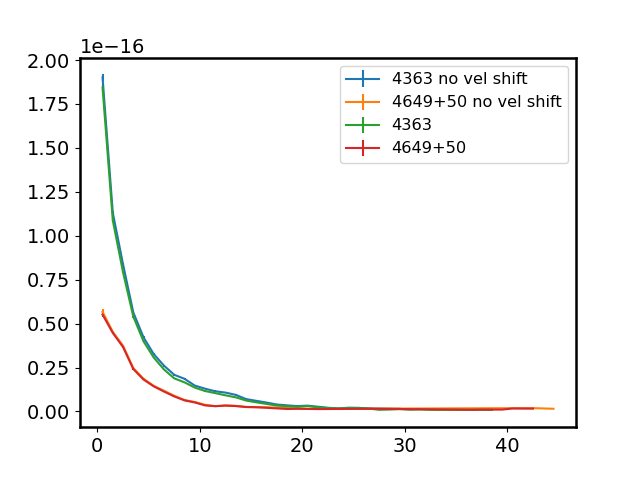

In [58]:
with fits.open('/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/annular_binned_flux_1.1.2dev0.fits') as hdu:
    header = hdu[1].header
    table1 = hdu[1].data

with fits.open(annbinned_flux) as hdu:
    header = hdu[1].header
    table2 = hdu[1].data


snr = table2['NII_OII_flux5']+table2['NII_OII_flux6']/np.sqrt(table2['NII_OII_flux5_err']**2+table2['NII_OII_flux6_err']**2)
sel = snr>3

snr1 = table1['NII_OII_flux5']+table1['NII_OII_flux6']/np.sqrt(table1['NII_OII_flux5_err']**2+table1['NII_OII_flux6_err']**2)
sel1 = snr1>3

snr_cel = table2['[OIII]4363_flux1']/table2['[OIII]4363_flux1_err']
selcel = snr_cel>3
snr_cel1 = table1['[OIII]4363_flux1']/table1['[OIII]4363_flux1_err']
selcel1 = snr_cel1>3

plt.errorbar(table1['distance'][selcel1], table1['[OIII]4363_flux1'][selcel1], yerr=table1['[OIII]4363_flux1_err'][selcel1], label='4363 no vel shift')
plt.errorbar(table1['distance'][sel1], (table1['NII_OII_flux5']+table1['NII_OII_flux6'])[sel1], yerr= np.sqrt(table1['NII_OII_flux5_err']**2+table1['NII_OII_flux6_err']**2)[sel1], label='4649+50 no vel shift')

plt.errorbar(table2['distance'][selcel], table2['[OIII]4363_flux1'][selcel], yerr=table2['[OIII]4363_flux1_err'][selcel], label='4363')
plt.errorbar(table2['distance'][sel], (table2['NII_OII_flux5']+table2['NII_OII_flux6'])[sel], yerr= np.sqrt(table2['NII_OII_flux5_err']**2+table2['NII_OII_flux6_err']**2)[sel], label='4649+50')
plt.legend()
plt.show()

In [26]:
'''

1.67934222e+01 3.33972835e+01 3.23752185e+01 2.57623003e+01
 2.43414680e+01 2.08176506e+01 1.92050160e+01 1.57448709e+01
 1.38291967e+01 1.09751206e+01 8.07559182e+00 7.55875100e+00
 8.46863347e+00 8.22776692e+00 6.61382266e+00 6.21790135e+00
 6.81216773e+00 2.58649528e+00 3.23917483e+00 3.85969924e+00
 4.29864300e+00 3.28886052e+00 2.75931731e+00 1.40563961e+00
 2.19391392e+00 1.96461700e+00 2.96986038e+00 2.25072982e+00
 1.71909951e+00 6.54006576e-19 6.26467748e-19 8.98159748e-01
 6.03358571e-02 1.43997885e+00 3.28135874e-34 1.71201915e+00
 3.17746245e+00 3.60144586e+00 2.50562642e+00 3.51765101e+00
 2.87795421e+00 2.39792349e+00 3.94388402e+00 2.05849756e+00
 3.88596527e+00 6.60490322e-21 1.39225727e+00 2.41575075e+00
 4.92819816e-01 1.42401797e-01 1.05026504e+00 9.69749978e-25
 3.82215625e-19

'''

'\n\n1.67934222e+01 3.33972835e+01 3.23752185e+01 2.57623003e+01\n 2.43414680e+01 2.08176506e+01 1.92050160e+01 1.57448709e+01\n 1.38291967e+01 1.09751206e+01 8.07559182e+00 7.55875100e+00\n 8.46863347e+00 8.22776692e+00 6.61382266e+00 6.21790135e+00\n 6.81216773e+00 2.58649528e+00 3.23917483e+00 3.85969924e+00\n 4.29864300e+00 3.28886052e+00 2.75931731e+00 1.40563961e+00\n 2.19391392e+00 1.96461700e+00 2.96986038e+00 2.25072982e+00\n 1.71909951e+00 6.54006576e-19 6.26467748e-19 8.98159748e-01\n 6.03358571e-02 1.43997885e+00 3.28135874e-34 1.71201915e+00\n 3.17746245e+00 3.60144586e+00 2.50562642e+00 3.51765101e+00\n 2.87795421e+00 2.39792349e+00 3.94388402e+00 2.05849756e+00\n 3.88596527e+00 6.60490322e-21 1.39225727e+00 2.41575075e+00\n 4.92819816e-01 1.42401797e-01 1.05026504e+00 9.69749978e-25\n 3.82215625e-19\n\n'

In [57]:
plt.close('all')

In [29]:
######################### On spatially resolved spectra, dec 5th #####################

def pyneb_ratio(Te, ne):
    atom = pn.RecAtom('H', 1)
    wavelengths = [3750.15, 3770.63, 3835.38, 4101.74, 4340.463, 4861.32, 6563.0, 8862.78, 9014.91, 9229.01]  # Hk, Hi, He, Hd, Hg, Hb, Ha, P11, P10, P9
    emis = np.array([atom.getEmissivity(tem=Te, den=ne, wave=wl) for wl in wavelengths])
    ratios = emis / emis[5]  # Normalize to Hβ
    return np.array(wavelengths), ratios


def extinction_curve(model, wavelength, Rv, Ebv):
    
    '''
    Calculating the extinction at a given wavelength based on Rv and E(B-V)
    model : model can be any exxtinction curve model such as F99
    wavelength : wavelength at which we wish to compute extinction curve value
    Rv : total to selective extinction -- will be an array of 2 or more elts
    Ebv : color excess value
    '''

    # Initializing the F99 extinction model, just as an example
    extinction_model = model(Rv)
    k_lambda = extinction_model(wavelength * u.AA)  
    return k_lambda * Ebv

# theoretical Balmer decrements 
balmer_theoretical = {
    'Hk':   [],
    'Hi':   [], 
    'He':   [],
    'Hd':   [],
    'Hg':   [],
    'Hb':   [],
    'Ha':   [],
    'P11':  [],
    'P10':  [],
    'P9' :  []
                }

_, ratios = pyneb_ratio(8000, 100)

# Assign ratios to the balmer_theoretical dictionary
keys = list(balmer_theoretical.keys())
for i, key in enumerate(keys):
    balmer_theoretical[key] = ratios[i]

# Opening integrated spectrum fits file to read observed fluxes
with fits.open(annbinned_flux) as hdu:
    #print(repr(hdu[1].header))
    data = hdu[1].data

# Wavelengths of the Balmer lines 
wavelengths = {
    
    'Hk': data['HI3750_wave0'],
    'Hi': data['HI3771_wave0'],
    'He': data['HI3835_wave0'],
    'Hd': data['HI4102_wave0'], 
    'Hg': data['Hgm4340_wave0'], 
    'Hb': data['Hb4861_wave0'], 
    'Ha': data['Ha6563_wave0'], 
    'P11': data['HI8863_wave0'],
    'P10': data['HI9015_wave0'],
    'P9' : data['HI9229_wave0'] 
                }

# Observed Balmer line fluxes 
observed_ratios = {

    'Hk':  data['HI3750_flux0']/(data['Hb4861_flux0']  ),  
    'Hi':  data['HI3771_flux0']/(data['Hb4861_flux0']  ), 
    'He':  data['HI3835_flux0']/(data['Hb4861_flux0']  ),
    'Hd':  data['HI4102_flux0']/(data['Hb4861_flux0']  ),
    'Hg':  data['Hgm4340_flux0']/(data['Hb4861_flux0'] ),
    'Hb':  data['Hb4861_flux0']/(data['Hb4861_flux0']  ),
    'Ha':  data['Ha6563_flux0']/(data['Hb4861_flux0']  ),
    'P11': data['HI8863_flux0']/(data['Hb4861_flux0']  ),
    'P10': data['HI9015_flux0']/(data['Hb4861_flux0']  ),
    'P9' : data['HI9229_flux0']/(data['Hb4861_flux0']  )
                  
                  }
# divide obs_ratios and modeled ratios with the theoretical values at 0 extinction
# calculate err on obs_ratios and plot it using errorbar func, overplot it with modeled obs_ratios

error_obs_ratios = {

    'Hk' : observed_ratios['Hk' ] * np.sqrt((data['HI3750_flux0_err']/data['HI3750_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hi' : observed_ratios['Hi' ] * np.sqrt((data['HI3771_flux0_err']/data['HI3771_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'He' : observed_ratios['He' ] * np.sqrt((data['HI3835_flux0_err']/data['HI3835_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hd' : observed_ratios['Hd' ] * np.sqrt((data['HI4102_flux0_err']/data['HI4102_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hg' : observed_ratios['Hg' ] * np.sqrt((data['Hgm4340_flux0_err']/data['Hgm4340_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'Hb' : observed_ratios['Hb' ] * np.sqrt(2) * (data['Hb4861_flux0_err'] / data['Hb4861_flux0']),
    'Ha' : observed_ratios['Ha' ] * np.sqrt((data['Ha6563_flux0_err']/data['Ha6563_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),    
    'P11': observed_ratios['P11'] * np.sqrt((data['HI8863_flux0_err']/data['HI8863_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'P10': observed_ratios['P10'] * np.sqrt((data['HI9015_flux0_err']/data['HI9015_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2),
    'P9' : observed_ratios['P9' ] * np.sqrt((data['HI9229_flux0_err']/data['HI9229_flux0'])**2 + (data['Hb4861_flux0_err']/data['Hb4861_flux0'])**2)

            }


# Define the mask
included_lines = [ 'Hd', 'Hg', 'Hb', 'P11', 'P9']  

mask = [line in included_lines for line in wavelengths.keys()]

# Convert the ratios to arrays
obs_ratios = np.array([observed_ratios[line] for line in wavelengths])[mask]
err_obs_ratios = np.array([error_obs_ratios[line] for line in wavelengths])[mask]
theor_ratios = np.array([balmer_theoretical[line] for line in wavelengths])[mask]
wave_array = np.array([wavelengths[line] for line in wavelengths])[mask]

theo_ratios = np.tile(theor_ratios, (len(data), 1)).T

# Initialize empty lists to store results for all spaxels

dist = []
ebv_list = []
ebv_err_list = []
chi_sqr_list = []
rv_list = []
rv_err_list = []

for i in range(len(data)):

    distance = data['distance'][i]
    wave_array_spaxel = wave_array[:, i]
    obs_ratios_spaxel = obs_ratios[:, i]
    err_obs_ratios_spaxel = err_obs_ratios[:, i]
    theo_ratios_spaxel = theo_ratios[:, i]

    print(f"bin no. {i+1}, distance {distance} arcmin")

    #print(ra, dec, wave_array_spaxel.shape, theo_ratios_spaxel.shape, obs_ratios_spaxel.shape)

    # Model function to fit
    def model_function(wavelength, Rv, Ebv):

        # Model for the observed line ratios affected by dust extinction
        extinction_factor = np.array([10**(-0.4 * (extinction_curve(F99, wave, Rv, Ebv) - 
                            extinction_curve(F99, wavelengths['Hb'][0], Rv, Ebv))) 
                            for wave in wavelength])

        #modeled_ratios = theo_ratios * extinction_factor
        modeled_ratios = theo_ratios_spaxel * extinction_factor  # normalizing wrt to the theoretical value: theo_ratios * extinction_factor/theo_ratios

        #print('modeled_ratios', modeled_ratios, 'obs_ratios_spaxel', obs_ratios_spaxel)
        
        #plt.errorbar(wave_array_spaxel, obs_ratios_spaxel.flatten(), yerr=err_obs_ratios_spaxel.flatten(), fmt='o', label ='Observed ratios')
        #plt.plot(wave_array_spaxel, modeled_ratios, label=f"Model at Rv: {Rv:.2f}, Ebv: {Ebv:.2f}")
        #plt.title(f'Observed vs modeled ratios, E(B-V):{Ebv:.2f}, Rv:{Rv:.2f}')
        #plt.xlabel(r'Wavelength ($\AA$)')
        #plt.ylabel('Ratio')
        #plt.show()
        #plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/integrated_spectrum/testing_Ebv_fits/obs_model_fit_Rv_{Rv:.3f}_Ebv_{Ebv:.3f}.png', dpi=300)

        return modeled_ratios


    # Fit function
    def fit_ebv(Rv):

        p0 = (Rv, 1)
        # Fit the model using curve_fit
        popt, pcov, infodict, mesg, ier = curve_fit(model_function, wave_array_spaxel, obs_ratios_spaxel.flatten(), sigma = err_obs_ratios_spaxel.flatten(), p0=p0, absolute_sigma=True, 
                            bounds = ((2, 0), (6, 5)), full_output = True)

        # Calcuating chi squared 
        fvec = infodict['fvec']
        chi_sqr = np.sum(fvec**2)/(len(theo_ratios_spaxel)-2)

        # Extract the best-fit E(B-V)
        best_fit_Ebv = popt[1]
        best_fit_Rv = popt[0]
        modeled_ratios_spaxel = model_function(wave_array_spaxel, best_fit_Rv, best_fit_Ebv)

        return best_fit_Rv, np.sqrt(pcov[0, 0]), best_fit_Ebv, np.sqrt(pcov[1, 1]), chi_sqr

    num = [2.1, 2.6, 3.1, 4.0, 5.0, 5.5, 5.8, 5.99]

    #for rv in num:
    #Calling fit_ebv function
    rv = 3.1

    best_rv, err_rv, best_Ebv, err_Ebv, best_chi = fit_ebv(rv)

    print(f"Best-fit E(B-V) for Rv = {best_rv}: {best_Ebv:.3f}, Ebv_err: {err_Ebv:.3f}, chi_sqr:{best_chi:.3f}")
    dist.append(distance)
    rv_list.append(best_rv)
    rv_err_list.append(err_rv)  
    ebv_list.append(best_Ebv)
    ebv_err_list.append(err_Ebv)
    chi_sqr_list.append(best_chi)

output_table = Table(
    [dist, rv_list, rv_err_list, ebv_list, ebv_err_list, chi_sqr_list],
    names=('distance', 'Rv', 'Rv_err', 'E(B-V)', 'E(B-V)_err', 'Chi_Sqr'))

output_table.write(data_dir+f'annbinned/annular_binned_rv_ebv.fits', overwrite=True)


bin no. 1, distance 0.5 arcmin
Best-fit E(B-V) for Rv = 5.999999999999999: 2.086, Ebv_err: 0.001, chi_sqr:2101.994
bin no. 2, distance 1.5 arcmin
Best-fit E(B-V) for Rv = 5.132655605597803: 1.740, Ebv_err: 0.001, chi_sqr:1894.423
bin no. 3, distance 2.5 arcmin
Best-fit E(B-V) for Rv = 4.637371560058068: 1.643, Ebv_err: 0.001, chi_sqr:868.851
bin no. 4, distance 3.5 arcmin
Best-fit E(B-V) for Rv = 4.227558474283831: 1.570, Ebv_err: 0.002, chi_sqr:904.775
bin no. 5, distance 4.5 arcmin
Best-fit E(B-V) for Rv = 3.8283696162185663: 1.440, Ebv_err: 0.002, chi_sqr:1055.987
bin no. 6, distance 5.5 arcmin
Best-fit E(B-V) for Rv = 3.9160896333093733: 1.409, Ebv_err: 0.002, chi_sqr:1271.763
bin no. 7, distance 6.5 arcmin
Best-fit E(B-V) for Rv = 3.7399451317382977: 1.346, Ebv_err: 0.002, chi_sqr:1067.425
bin no. 8, distance 7.5 arcmin
Best-fit E(B-V) for Rv = 3.656600248597171: 1.317, Ebv_err: 0.002, chi_sqr:750.829
bin no. 9, distance 8.5 arcmin
Best-fit E(B-V) for Rv = 3.6496499924504278: 1.31

No such comm: 0abdba0bee0342119f0c661c4a227e83
No such comm: 0abdba0bee0342119f0c661c4a227e83


No such comm: f749b0a6dbd44c34989cdfc4751861b4


In [46]:
#varyinng Rv and ebv
'''
bin no. 1, distance 0.5 arcmin
Best-fit E(B-V) for Rv = 5.999999999999999: 2.019, Ebv_err: 0.002, chi_sqr:1942.538
bin no. 2, distance 1.5 arcmin
Best-fit E(B-V) for Rv = 5.219294012197224: 1.744, Ebv_err: 0.001, chi_sqr:2996.386
bin no. 3, distance 2.5 arcmin
Best-fit E(B-V) for Rv = 4.687940029427082: 1.641, Ebv_err: 0.001, chi_sqr:1530.068
bin no. 4, distance 3.5 arcmin
Best-fit E(B-V) for Rv = 4.282385458491026: 1.552, Ebv_err: 0.002, chi_sqr:2103.530
bin no. 5, distance 4.5 arcmin
Best-fit E(B-V) for Rv = 3.9718215785809905: 1.452, Ebv_err: 0.002, chi_sqr:2345.471
bin no. 6, distance 5.5 arcmin
Best-fit E(B-V) for Rv = 3.97945608452443: 1.407, Ebv_err: 0.002, chi_sqr:2359.726
bin no. 7, distance 6.5 arcmin
Best-fit E(B-V) for Rv = 3.733420920516022: 1.342, Ebv_err: 0.002, chi_sqr:2329.842

'''

'\nbin no. 1, distance 0.5 arcmin\nBest-fit E(B-V) for Rv = 5.999999999999999: 2.019, Ebv_err: 0.002, chi_sqr:1942.538\nbin no. 2, distance 1.5 arcmin\nBest-fit E(B-V) for Rv = 5.219294012197224: 1.744, Ebv_err: 0.001, chi_sqr:2996.386\nbin no. 3, distance 2.5 arcmin\nBest-fit E(B-V) for Rv = 4.687940029427082: 1.641, Ebv_err: 0.001, chi_sqr:1530.068\nbin no. 4, distance 3.5 arcmin\nBest-fit E(B-V) for Rv = 4.282385458491026: 1.552, Ebv_err: 0.002, chi_sqr:2103.530\nbin no. 5, distance 4.5 arcmin\nBest-fit E(B-V) for Rv = 3.9718215785809905: 1.452, Ebv_err: 0.002, chi_sqr:2345.471\nbin no. 6, distance 5.5 arcmin\nBest-fit E(B-V) for Rv = 3.97945608452443: 1.407, Ebv_err: 0.002, chi_sqr:2359.726\nbin no. 7, distance 6.5 arcmin\nBest-fit E(B-V) for Rv = 3.733420920516022: 1.342, Ebv_err: 0.002, chi_sqr:2329.842\n\n'

In [60]:
hdu = fits.open(data_dir+f'annbinned/annular_binned_rv_ebv.fits')
data = hdu[1].data
dist = data['distance']

def calculate_extinction(rv_array, line_wavelength):
    
    A_line = np.zeros(len(data))
    A_line_err = np.zeros(len(data))

    for j, rv in enumerate(rv_array):

        extinction_model = F99(Rv=rv)
        f_line = extinction_model(line_wavelength * u.AA)
        A_line[j] = data['E(B-V)'][j] * f_line
        A_line_err[j] = data['E(B-V)_err'][j] * f_line


    return A_line, A_line_err

def dust_corr_all_ratios(filename, lines_to_correct):
    
    with fits.open(filename) as hdul:
        table = hdul[1].data
    
    # Prepare new columns
    new_columns = []
    for key in table.columns.names:
        if "flux" in key or "distance" in key or "npix" in key:
            obs_col_name = f"obs_{key}"
            new_columns.append(fits.Column(name=obs_col_name, format="D", array=table[key]))

    # Loop over lines to correct
    offsets = [0, 14.19, 23.38, 31.69, 34.65, 41.97, 43.68, 51.01, 54.47, 69.07]

    for line_label in lines_to_correct:

        for i in range(10):  # Correcting up to 10 components

            flux_column = f"{line_label}_flux{i}"
            flux_err_column = f"{line_label}_flux{i}_err"
            wave_column = f"{line_label}_wave{i}"

            if flux_column in table.columns.names:

                if line_label == 'NII_OII':
                    line_wavelength = 4607.16 + offsets[i]  # Using the above provided offsets

                elif line_label == '[OIII]4363':
                    line_wavelength = 4363.2 

                else:
                    line_wavelength = (
                    table[wave_column][0])
                
                if line_wavelength == 0:
                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format="D", array=table[flux_column]))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format="D", array=table[flux_err_column]))

                else:

                    A_line, A_line_err = calculate_extinction(data['Rv'], line_wavelength)
                    observed_flux = table[flux_column]
                    observed_flux_err = table[flux_err_column]

                    intrinsic_flux = observed_flux * 10 ** (0.4 * A_line)
                    intrinsic_flux_err = observed_flux_err * 10 ** (0.4 * A_line)

                    # Calculate intrinsic flux error
                    #error = np.sqrt(
                    #    (observed_flux_err / observed_flux) ** 2 + 
                    #    (0.4 * A_line_err * np.log(10)) ** 2)         # A_line_error should be considered but now we neglect ebv_err
                    # intrinsic_flux_err = intrinsic_flux * error

                    #intrinsic_flux_err = observed_flux_err * 10 ** (0.4 * A_line)

                    int_flux_col_name = f"int_{flux_column}"
                    int_flux_err_col_name = f"int_{flux_err_column}"
                    new_columns.append(fits.Column(name=int_flux_col_name, format="D", array=intrinsic_flux))
                    new_columns.append(fits.Column(name=int_flux_err_col_name, format="D", array=intrinsic_flux_err))

    # Add E(B-V) columns
    new_columns.append(fits.Column(name="E(B-V)", format="D", array=data['E(B-V)'] * np.ones(len(table))))
    new_columns.append(fits.Column(name="E(B-V)_err", format="D", array=data['E(B-V)_err'] * np.ones(len(table))))
    new_columns.append(fits.Column(name="Rv", format="D", array=data['Rv'] * np.ones(len(table))))
    new_columns.append(fits.Column(name="Rv_err", format="D", array=data['Rv_err'] * np.ones(len(table))))
    new_columns.append(fits.Column(name="A", format="D", array= A_line))
    #new_columns.append(fits.Column(name="A_err", format="D", array= A_line_err))

    print(f"Rv: {np.nanmedian(data['Rv'])}, Ebv:{np.nanmedian(data['E(B-V)'])}, Av:{np.nanmedian(A_line)}")


    # Write to a new FITS file
    cols = fits.ColDefs(new_columns)
    hdu = fits.BinTableHDU.from_columns(cols)

    output_filename = annbinned_corr_flux
    hdu.writeto(output_filename, overwrite=True)
    
    print(f"File saved: {output_filename}")

# Input
filename = annbinned_flux

lines_to_correct = {

    'HI3750': [3750.15],
    'HI3771': [3770.63],
    'HI3835': [3835.38], 
    'HI4102': [4101.74], 
    'Ha6563': [6562.8],
    'Hb4861': [4861.32],
    'Hgm4340': [4340.463] ,
    'NII_OII' : [4607.16] ,
    '[SII]4069': [4068.6] ,
    '[SII]6717': [6716.44],
    '[SII]6731': [6730.82],
    '[NII]5755': [5754.64],
    '[NII]6548': [6548.04],
    '[NII]6584': [6583.46],
    '[OIII]4363': [4363.2],
    '[OIII]4959': [4958.91],
    '[OIII]5007': [5006.84],
    '[OII]3726': [3726.03],
    '[OII]7320': [7319.99],
    '[OII]7330': [7330],
    '[ClIII]5517':[5517.71],
    '[ClIII]5537':[5537.88],
    'CII4267':[4267.09],
    'HI8863': [8862.78],
    'HI9015': [9014.91],
    'HI9229': [9229.01],
    '[SIII]6312': [6312.1],
    '[SIII]9069': [9068.6],
    '[SIII]9531': [9530.6]

    }

dust_corr_all_ratios(filename, lines_to_correct)


Rv: 3.4494623855421858, Ebv:1.381734879115498, Av:0.5813181862243544
File saved: /Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/annbinned/july8_25/annular_binned_obs_corr_flux_1.1.2dev0_spax_weighted_velocity_corrected.fits


In [ ]:
plt.plot()

In [48]:
'''
#################################### Bin spaxels in 1 arcmin annular width ###############################################

def const_radialbin(data, lineid='[OIII]4363', rmin=0, rmax=80):

    This function will provide the binned line flux for each lineid in each spaxel with constant bin width.

    Input:
    data: loading the full table
    lineid: rest frame wavelength of emission lines

    Returns:
    Radially binned flux, error spectrum with constant width

    
    rbinleft = [rmin]
    rbinright = []
    snbin = []
    npix = []
    
    flux = data['obs_flux']
    error = data['obs_error']
    wave = data['wave'][0]

    signal, noise = data1['obs_'+lineid+'_flux1'], data1['obs_'+lineid+'_flux1_err']

    # Initializing Radii
    RA = data['RA']
    Dec = data['Dec']

    # Assuming Her 36 binary as center for RA and Dec coordinates
    ra_hms = '18 03 40.3201232304'
    dec_dms = '-24 22 42.857540472'

    # Create a SkyCoord object
    coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

    # Converting ra and dec to degrees
    ra_center_deg = coord.ra.deg
    dec_center_deg = coord.dec.deg

    # Calculating the angular distance in degrees
    angular_distances_deg = np.sqrt(((RA - ra_center_deg) * np.cos(np.radians(dec_center_deg)))**2 + (Dec - dec_center_deg)**2)

    # Converting angular distances from degrees to arcminutes
    angular_distances_arcmin = angular_distances_deg * 60  

    radius = angular_distances_arcmin  # for arcminutes

    # Selecting bins based on radius parameters
    selected = (radius >= rmin) & (radius < rmax)
    radius_unique = np.unique(radius[selected])

    snbinned_flux = []
    snbinned_err = []

    cnt = 0
    bin_width = 1  # arcminute wide bins

    current_bin_left = rmin

    while current_bin_left < rmax:
        current_bin_right = current_bin_left + bin_width
        indices = (radius >= current_bin_left) & (radius < current_bin_right) & selected
        snr_rad = np.nansum(signal[indices]) / np.sqrt(np.nansum(noise[indices]**2))

        if np.any(indices):
            rbinright.append(current_bin_right)
            rbinleft.append(current_bin_left)
            npix.append(np.sum(indices))
            snbin.append(snr_rad)

        if np.sum(indices) > 0:
            snbinned_flux.append(np.nansum(flux[indices, :], axis=0) / npix[-1])
            snbinned_err.append(np.sqrt(np.nansum((error[indices, :]**2), axis=0)) / npix[-1])

        current_bin_left = current_bin_right
        cnt += 1

    snbinned_flux = np.array(snbinned_flux)
    snbinned_err = np.array(snbinned_err)

    # Writing headers in the fits file
    header = fits.Header()
    hdu_primary = fits.PrimaryHDU(header=header)
    hdu_target = fits.ImageHDU(data=snbinned_flux, name='flux') 
    hdu_errors = fits.ImageHDU(data=snbinned_err, name='error')
    hdu_wave = fits.ImageHDU(data=wave, name='wave')

    newtable = {
        'npix': npix,
        'right_bin': rbinright,
        'sn_bin': snbin
    }
    
    newtable = Table(newtable)
    hdu_table = fits.BinTableHDU(newtable, name='table')
    hdul = fits.HDUList([hdu_primary, hdu_target, hdu_errors, hdu_wave, hdu_table])

    filename = '/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/annular_binned/lagoon_4363_radbinned_observed_spectrum_arcmins.fits'
    hdul.writeto(filename, overwrite=True)

'''

"\n#################################### Bin spaxels in 1 arcmin annular width ###############################################\n\ndef const_radialbin(data, lineid='[OIII]4363', rmin=0, rmax=80):\n\n    This function will provide the binned line flux for each lineid in each spaxel with constant bin width.\n\n    Input:\n    data: loading the full table\n    lineid: rest frame wavelength of emission lines\n\n    Returns:\n    Radially binned flux, error spectrum with constant width\n\n    \n    rbinleft = [rmin]\n    rbinright = []\n    snbin = []\n    npix = []\n    \n    flux = data['obs_flux']\n    error = data['obs_error']\n    wave = data['wave'][0]\n\n    signal, noise = data1['obs_'+lineid+'_flux1'], data1['obs_'+lineid+'_flux1_err']\n\n    # Initializing Radii\n    RA = data['RA']\n    Dec = data['Dec']\n\n    # Assuming Her 36 binary as center for RA and Dec coordinates\n    ra_hms = '18 03 40.3201232304'\n    dec_dms = '-24 22 42.857540472'\n\n    # Create a SkyCoord object\n   

In [49]:
plt.close('all')

In [36]:
'''
This function will use the line fluxes to calculate the Te, ne and errors in Te nad ne running a MonteCarlo.
The function uses the following diagnostics:

TeO2: Te from "[OII] 3727+/7325+"  ; ne = 120 cm-3
TeO3: Te from "[OIII] 4363/5007"   ; ne = 120 cm-3
TeN2: Te from "[NII] 5755/6584"    ; ne = 120 cm-3
TeS2: Te from "[SII] 4072+/6720+"  ; ne = 120 cm-3
TeS3: Te from "[SIII] 6312/9069"   ; ne = 120 cm-3
neO2: ne from 3726/3729 ; Te=TeN2
neS2: ne from 6731/6716 ; Te=TeN2

input:
niter: number of MC realizations used to get errors on temperature and density, default is niter=10 (int)
nfib: no of fibers correspons to no. of spectrum for which we have linefluxes to compute Te, ne, etc.

Output:
TeO3=electron temperature from O3 diagnostic
TeO3err=error on electron temperature from O3 diagnostic, similar for all other Te diagnostics

neS2=electron density from S2 diagnostic 
neS2err=error on electron density from OS2 diagnostic, similar for all other ne diagnostics
'''

diagnostics_dict = {
    'distance': [],
    'distance_right': [],
    'npix': [],
    'neO2' : [],
    'neS2' : [],
    'neO2err' : [],
    'neS2err' : [],

    'TeO2' : [],   
    'TeO3' : [],
    'TeN2' : [],  


    'TeO2err' : [],  
    'TeO3err' : [],
    'TeN2err' : [],  

    'Opp_cel' : [],
    'Opp_cel_err' : [],

    'Op_cel' : [],
    'Op_cel_err' : [],

    'Opp_RL_abund':[],
    'Opp_RL_abund_err':[]}

with fits.open(annbinned_corr_flux) as hdu:
    header = hdu[1].header
    table = hdu[1].data

    Te =  8000

    nfib = len(table['int_NII_OII_flux0'])
    niter = 50

    print('shape of table:', table.shape)

    # Load PyNeb packages
    atoms = pn.getAtomDict()
    O3 = pn.Atom('O', 3)
    S2 = pn.Atom('S', 2)
    N2 = pn.Atom('N', 2)
    O2 = pn.Atom('O', 2)
    O2r = pn.RecAtom('O', 2)

    diagnostics_dict['distance'] = table['obs_distance'].flatten()
    diagnostics_dict['distance_right'] = table['obs_distance_right'].flatten()
    diagnostics_dict['npix'] = table['obs_npix'].flatten()

########################################## Function to perform Monte Carlo simulation #######################################
def mc_sim(flux, flux_err):
    return np.random.normal(flux, flux_err)

################################################## Electron density diagnostics, 1st iteration #################################################
# NO2 electron density diagnostic
NO2=np.zeros((nfib, niter))
for i in range (niter):
    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    NO2[:,i]=O2.getTemDen(f3726/f3729, tem=Te, wave1=3726, wave2=3729)

neO2 = np.nanmean(NO2, axis=1)
neO2err = np.nanstd(NO2, axis=1)

print('1st iteration mean NO2', np.nanmean(NO2))
print('1st iteration mean NO2err', (np.nanstd(NO2)))


# NS2 electron density diagnostic
NS2=np.zeros((nfib, niter))
for i in range (niter):
    f6717 = mc_sim(table['int_[SII]6717_flux0'], table['int_[SII]6717_flux0_err'])
    f6731 = mc_sim(table['int_[SII]6731_flux0'], table['int_[SII]6731_flux0_err'])
    NS2[:,i]=S2.getTemDen(f6717/f6731, tem=Te, wave1=6717, wave2=6731) 

neS2 = np.nanmean(NS2, axis=1)
neS2err = np.nanstd(NS2, axis=1)

print('1st iteration mean NO2', neS2)
print('1st iteration mean NO2err', neS2err)

neS2_mc = mc_sim(neS2, neS2err)

############################################################### Ten2 ############################################################
# TN2 temperature diagnostic
TN2=np.zeros((nfib, niter))

for i in range (niter):
    f5755=table['int_[NII]5755_flux0']+np.random.randn(nfib)*table['int_[NII]5755_flux0_err']
    f6584=table['int_[NII]6584_flux0']+np.random.randn(nfib)*table['int_[NII]6584_flux0_err']
    TN2[:,i]=N2.getTemDen(f5755/f6584, den=neS2_mc, wave1=5755, wave2=6584)

TeN2 = np.nanmean(TN2, axis=1)
TeN2err = np.nanstd(TN2, axis=1)

print('1st iteration mean TeN2', np.nanmean(TN2))
print('1st iteration mean TeN2_err', (np.nanstd(TN2)))


TeN2_mc = mc_sim(TeN2, TeN2err) 

###########################################################################################################################################

##################################################### second iteration #######################################################
# Neo2 and S2 electron density diagnostic

NO2=np.zeros((nfib, niter))
for i in range (niter):
    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    NO2[:,i]=O2.getTemDen(f3726/f3729, tem=TeN2_mc, wave1=3726, wave2=3729)

neO2 = np.nanmean(NO2, axis=1)
neO2err = np.nanstd(NO2, axis=1)

print('2nd iteration mean NO2', np.nanmean(NO2))
print('2nd iteration mean NO2err', (np.nanstd(NO2)))


# NS2 electron density diagnostic
NS2=np.zeros((nfib, niter))
for i in range (niter):
    f6717 = mc_sim(table['int_[SII]6717_flux0'], table['int_[SII]6717_flux0_err'])
    f6731 = mc_sim(table['int_[SII]6731_flux0'], table['int_[SII]6731_flux0_err'])
    NS2[:,i]=S2.getTemDen(f6717/f6731, tem=TeN2_mc, wave1=6717, wave2=6731) 

neS2 = np.nanmean(NS2, axis=1)
neS2err = np.nanstd(NS2, axis=1)
print('2nd iteration mean NS2', np.nanmean(neS2))
print('2nd iteration mean NS2err', (np.nanstd(neS2err)))
neS2_mc = mc_sim(neS2, neS2err)

# TN2 temperature diagnostic
TN2=np.zeros((nfib, niter))

for i in range (niter):
    f5755=table['int_[NII]5755_flux0']+np.random.randn(nfib)*table['int_[NII]5755_flux0_err']
    f6584=table['int_[NII]6584_flux0']+np.random.randn(nfib)*table['int_[NII]6584_flux0_err']
    TN2[:,i]=N2.getTemDen(f5755/f6584, den=neS2_mc, wave1=5755, wave2=6584)

TeN2 = np.nanmean(TN2, axis=1)
TeN2err = np.nanstd(TN2, axis=1)

print('2nd iteration mean TeN2', np.nanmean(TN2))
print('2nd iteration mean TeN2_err', (np.nanstd(TN2)))  
TeN2_mc = mc_sim(TeN2, TeN2err) 

###################################################################################################################################################
##################################################### thirdd iteration #######################################################
# Neo2 and S2 electron density diagnostic

NO2=np.zeros((nfib, niter))
for i in range (niter):
    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    NO2[:,i]=O2.getTemDen(f3726/f3729, tem=TeN2_mc, wave1=3726, wave2=3729)

neO2 = np.nanmean(NO2, axis=1)
neO2err = np.nanstd(NO2, axis=1)

print('mean NO2', np.nanmean(NO2))
print('mean NO2err', (np.nanstd(NO2)))
diagnostics_dict['neO2']=neO2
diagnostics_dict['neO2err']=neO2err   

# NS2 electron density diagnostic
NS2=np.zeros((nfib, niter))
for i in range (niter):
    f6717 = mc_sim(table['int_[SII]6717_flux0'], table['int_[SII]6717_flux0_err'])
    f6731 = mc_sim(table['int_[SII]6731_flux0'], table['int_[SII]6731_flux0_err'])
    NS2[:,i]=S2.getTemDen(f6717/f6731, tem=TeN2_mc, wave1=6717, wave2=6731) 

neS2 = np.nanmean(NS2, axis=1)
neS2err = np.nanstd(NS2, axis=1)
print('mean NS2', np.nanmean(neS2))
print('mean NS2err', (np.nanstd(neS2err)))

diagnostics_dict['neS2']=neS2
diagnostics_dict['neS2err']=neS2err   

neS2_mc = mc_sim(neS2, neS2err)

# TN2 temperature diagnostic
TN2=np.zeros((nfib, niter))

for i in range (niter):
    f5755=table['int_[NII]5755_flux0']+np.random.randn(nfib)*table['int_[NII]5755_flux0_err']
    f6584=table['int_[NII]6584_flux0']+np.random.randn(nfib)*table['int_[NII]6584_flux0_err']
    TN2[:,i]=N2.getTemDen(f5755/f6584, den=neS2_mc, wave1=5755, wave2=6584)

TeN2 = np.nanmean(TN2, axis=1)
TeN2err = np.nanstd(TN2, axis=1)

print('mean TeN2', np.nanmean(TN2))
print('mean TeN2_err', (np.nanstd(TN2)))

diagnostics_dict['TeN2']=TeN2
diagnostics_dict['TeN2err']=TeN2err    

TeN2_mc = mc_sim(TeN2, TeN2err) 

###################################################################################################################################################


# TO2 temperature diagnostic
TO2=np.zeros((nfib, niter))
for i in range (niter):
    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    f7320 = mc_sim(table['int_[OII]7320_flux0'], table['int_[OII]7320_flux0_err'])
    f7330 = mc_sim(table['int_[OII]7330_flux0'], table['int_[OII]7330_flux0_err'])

    TO2[:,i] = O2.getTemDen((f7330)/(f3726+f3729), den=neS2_mc, to_eval = '(L(7320)+L(7330))/(L(3726)+L(3729))')

TeO2 = np.nanmean(TO2, axis=1)
TeO2err = np.nanstd(TO2, axis=1)

print('mean TeO2', TeO2)
print('mean TeO2_err', TeO2err)

diagnostics_dict['TeO2']=TeO2
diagnostics_dict['TeO2err']=TeO2err


# TO3 temperature diagnostic
TO3 = np.zeros((nfib, niter))
for i in range (niter):
    f4363 = mc_sim(table['int_[OIII]4363_flux1'], table['int_[OIII]4363_flux1_err'])
    f5007 = mc_sim(table['int_[OIII]5007_flux0'], table['int_[OIII]5007_flux0_err'])
    f4959 = mc_sim(table['int_[OIII]4959_flux0'], table['int_[OIII]4959_flux0_err'])
    TO3[:,i] = O3.getTemDen((f4363)/(f5007+f4959), den=neS2_mc, to_eval = 'L(4363)/(L(5007)+L(4959))')

TeO3 = np.nanmean(TO3, axis=1)
TeO3err = np.nanstd(TO3, axis=1)

print('mean TeO3', np.nanmean(TeO3))
print('mean TeO3_err',  np.nanstd(TeO3))    

diagnostics_dict['TeO3']=TeO3
diagnostics_dict['TeO3err']=TeO3err
##########################################################################################################################
TeO2_mc = mc_sim(TeO2, TeO2err)
TeO3_mc = mc_sim(TeO3, TeO3err) 



############################################################## Calculating ionic abunadnces #################################################

# Calculating ionic abundance for following ions
# O+/H+ ionic abundance
Op_cel=np.zeros((nfib, niter))
for i in range (niter):
    f3726 = mc_sim(table['int_[OII]3726_flux0'], table['int_[OII]3726_flux0_err'])
    f3729 = mc_sim(table['int_[OII]3726_flux1'], table['int_[OII]3726_flux1_err'])
    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])
    
    Int_Oph = np.divide((f3726+f3729),f4861)
    Op_cel[:,i]=12+np.log10(O2.getIonAbundance(int_ratio=100*(Int_Oph), tem= TeN2_mc, den= neS2_mc, to_eval='L(3726)+L(3729)'))

diagnostics_dict['Op_cel']=np.nanmean(Op_cel, axis=1)
diagnostics_dict['Op_cel_err']= np.nanstd(Op_cel, axis=1)

print('mean Op_cel', np.nanmean(Op_cel))
print('mean Op_cel_err', np.nanstd(Op_cel))


#############################################################################################################################
## O++/H+ ionic abundance
Opp_cel=np.zeros((nfib, niter))
for i in range (niter):
    
    f5007 = mc_sim(table['int_[OIII]5007_flux0'], table['int_[OIII]5007_flux0_err'])
    f4959 = mc_sim(table['int_[OIII]4959_flux0'], table['int_[OIII]4959_flux0_err'])
    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])
    
    Int_Opph = np.divide((f5007+f4959),f4861)
    Opp_cel[:,i]=12+np.log10(O3.getIonAbundance(int_ratio=100*(Int_Opph), tem= TeO3_mc, den= neS2_mc, to_eval='L(5007)+L(4959)'))

diagnostics_dict['Opp_cel']=np.nanmean(Opp_cel, axis=1)
diagnostics_dict['Opp_cel_err']= np.nanstd(Opp_cel, axis=1)

print('mean Opp_cel', np.nanmean(Opp_cel))
print('mean Opp_cel_err', (np.nanstd(Opp_cel)))

############################################################################################################################
Opp_RL=np.zeros((nfib, niter))
for i in range (niter):
    f4638 = mc_sim(table['int_NII_OII_flux3'], table['int_NII_OII_flux3_err'])
    f4641 = mc_sim(table['int_NII_OII_flux4'], table['int_NII_OII_flux4_err'])
    f4649 = mc_sim(table['int_NII_OII_flux5'], table['int_NII_OII_flux5_err'])
    f4650 = mc_sim(table['int_NII_OII_flux6'], table['int_NII_OII_flux6_err'])
    f4662 = mc_sim(table['int_NII_OII_flux8'], table['int_NII_OII_flux8_err'])
    f4676 = mc_sim(table['int_NII_OII_flux9'], table['int_NII_OII_flux9_err'])       
    f4861 = mc_sim(table['int_Hb4861_flux0'], table['int_Hb4861_flux0_err'])
    
    Int_OII_v2 = np.divide((f4638+f4641+f4649+f4650+f4662+f4676), f4861)
    Opp_RL[:,i] =12 + np.log10( O2r.getIonAbundance (int_ratio=(Int_OII_v2)*100, tem= TeO3_mc, den= neS2_mc, to_eval='L(4638.86)+L(4641.81)+L(4649.13)+L(4650.84)+L(4661.63)+L(4676.23)'))

print()
diagnostics_dict['Opp_RL']= np.nanmean(Opp_RL, axis=1)
diagnostics_dict['Opp_RL_err']= np.nanstd(Opp_RL, axis=1)
print(np.nanmean(Opp_RL))

# All lists have the same length by filling missing values with zeros
max_length = max(len(lst) for lst in diagnostics_dict.values())

for key in diagnostics_dict:
    if len(diagnostics_dict[key]) < max_length:
        diagnostics_dict[key].extend([0] * (max_length - len(diagnostics_dict[key])))
 
diagnostics_dict = {key: np.array(value) for key, value in diagnostics_dict.items()}

table = Table(diagnostics_dict)

# Write the table to a FITS file
table.write(annbinned_diag, format='fits', overwrite=True)



shape of table: (53,)
warng _ManageAtomicData: rec data not available for Al2
warng _ManageAtomicData: rec data not available for Ar2
warng _ManageAtomicData: rec data not available for Ar3
warng _ManageAtomicData: rec data not available for Ar4
warng _ManageAtomicData: rec data not available for Ar5
warng _ManageAtomicData: rec data not available for Ba2
warng _ManageAtomicData: rec data not available for Ba4
ERROR None: No data for this case B
ERROR None: No data for this case B
warng _ManageAtomicData: rec data not available for Ca5
warng _ManageAtomicData: rec data not available for Cl2
warng _ManageAtomicData: rec data not available for Cl3
warng _ManageAtomicData: rec data not available for Cl4
warng _ManageAtomicData: rec data not available for Fe3
warng _ManageAtomicData: rec data not available for K4
warng _ManageAtomicData: rec data not available for K5
warng _ManageAtomicData: rec data not available for Mg5
warng _ManageAtomicData: rec data not available for Mg7
ERROR None: 

/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_38201/4101442359.py:322: RuntimeWarning: invalid value encountered in log10
  Opp_RL[:,i] =12 + np.log10( O2r.getIonAbundance (int_ratio=(Int_OII_v2)*100, tem= TeO3_mc, den= neS2_mc, to_eval='L(4638.86)+L(4641.81)+L(4649.13)+L(4650.84)+L(4661.63)+L(4676.23)'))



8.566250347557935


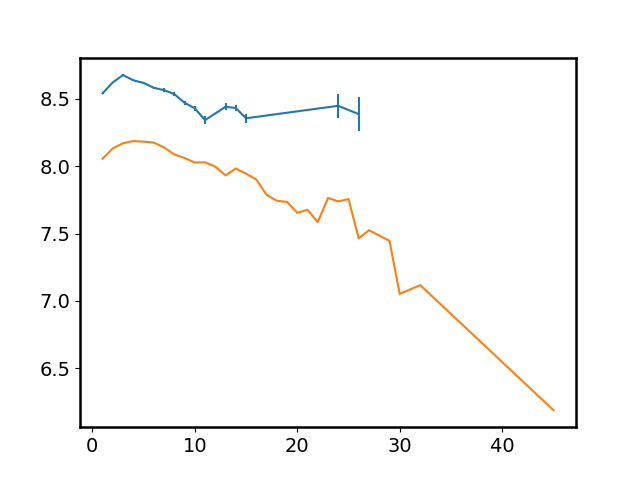

In [39]:
with fits.open(annbinned_corr_flux) as hdu:
    header = hdu[1].header
    table2 = hdu[1].data

snr = table2['int_NII_OII_flux5']/table2['int_NII_OII_flux5_err']
sel = snr>3
snr_cel = table2['int_[OIII]4363_flux1']/table2['int_[OIII]4363_flux1_err']
selcel = snr_cel>3
plt.errorbar(diagnostics_dict['distance_right'][sel], diagnostics_dict['Opp_RL'][sel], yerr=diagnostics_dict['Opp_RL_err'][sel])
plt.errorbar(diagnostics_dict['distance_right'][selcel], diagnostics_dict['Opp_cel'][selcel], yerr=diagnostics_dict['Opp_cel_err'][selcel])

plt.show()

In [38]:
plt.close()

In [40]:
elemental_abund_O = 12 + np.log10(10 ** (diagnostics_dict['Opp_cel'] - 12) + 10 ** (diagnostics_dict['Op_cel'] - 12))
#elemental_abund_O_new = 12 + np.log10(10**(np.nanmean(Opp_celnew, axis = 0)-12) + 10 ** (np.nanmean(Op_celnew, axis = 0) - 12))

op_abundance_err =  diagnostics_dict['Op_cel_err']  
opp_abundance_err = diagnostics_dict['Opp_cel_err']  
#op_abundance_err_new = np.nanstd(Op_celnew, axis = 0)
#opp_abundance_err_new = np.nanstd(Opp_celnew, axis = 0)

total_oxygen_abundance_err = np.sqrt(op_abundance_err**2 + opp_abundance_err**2)
#total_oxygen_abundance_err_new = np.sqrt(op_abundance_err_new**2 + opp_abundance_err_new**2)

print(np.nanmean(elemental_abund_O), np.nanmean(total_oxygen_abundance_err))
#print(elemental_abund_O_new, total_oxygen_abundance_err_new)

elemental_abund_O = 12 + np.log10(10 ** (diagnostics_dict['Opp_RL'] - 12) + 10 ** (diagnostics_dict['Op_cel'] - 12))
#elemental_abund_O_new = 12 + np.log10(10**(np.nanmean(Opp_RLnew, axis = 0)-12) + 10 ** (np.nanmean(Op_celnew, axis = 0) - 12))

op_abundance_err =  diagnostics_dict['Op_cel_err']  
opp_abundance_err = diagnostics_dict['Opp_RL_err']  
#op_abundance_err_new = np.nanstd(Op_celnew, axis = 0)
#opp_abundance_err_new = np.nanstd(Opp_RLnew, axis = 0)

total_oxygen_abundance_err = np.sqrt(op_abundance_err**2 + opp_abundance_err**2)
#total_oxygen_abundance_err = np.sqrt(op_abundance_err_new**2 + opp_abundance_err_new**2)

print(np.nanmean(elemental_abund_O), np.nanmean(total_oxygen_abundance_err))
#print(elemental_abund_O_new, total_oxygen_abundance_err_new)

def calculate_adf(Opp_cel, Opp_rl, Opp_cel_err, Opp_rl_err):

    Opp_RL_abund_linear = 10**(Opp_rl - 12)
    Opp_cel_linear = 10**(Opp_cel - 12)

    # errors to linear scale
    Opp_RL_abund_linear_err = Opp_RL_abund_linear * np.log(10) * Opp_rl_err
    Opp_cel_linear_err = Opp_cel_linear * np.log(10) * Opp_cel_err

    # ADF in linear scale
    ADF_linear = Opp_RL_abund_linear / Opp_cel_linear

    # error on ADF in linear scale
    ADF_linear_err = ADF_linear * np.sqrt((Opp_RL_abund_linear_err / Opp_RL_abund_linear)**2 + 
                                          (Opp_cel_linear_err / Opp_cel_linear)**2)

    # ADF and its error back to logarithmic scale
    dex = np.log10(ADF_linear)
    err_dex = ADF_linear_err / (ADF_linear * np.log(10))

    print(f"ADF: {dex}, error on ADF: {err_dex}")

    return dex, err_dex

dex, err_dex= calculate_adf(diagnostics_dict['Opp_cel'], diagnostics_dict['Opp_RL'], diagnostics_dict['Opp_cel_err'], diagnostics_dict['Opp_RL_err'])

#calculate_adf(np.nanmean(Opp_celnew, axis = 0), np.nanmean(Opp_RLnew, axis = 0), np.nanstd(Opp_celnew, axis = 0), np.nanstd(Opp_RLnew, axis = 0))


8.497122545721655 0.0014965342381619495
8.80427899847703 0.13431545227958702
ADF: [0.48476109 0.48960143 0.50500106 0.45032879 0.43567928 0.40653211
 0.42421704 0.44816892 0.40911699 0.40187378 0.31327056 0.32539759
 0.50885086 0.44860723 0.4108555  0.48685334 0.6984366  0.54225091
 0.58882821 0.82662969 0.84591517 0.91377007 0.69207544 0.70874528
 1.2674459  0.92073029 0.8857305  0.95371074 1.10067014 1.41818475
 1.28785005 1.55057819 1.29549989 0.69003968 1.06003728 0.86825048
 1.59142392 1.79714696 1.75638768 1.73996518 1.90599834 1.74467392
 2.35481643 1.90639256 2.78816448 2.0625152  1.93748065 2.18854242
 1.89292536 1.9594206  2.40118661 1.57029213 2.49518322], error on ADF: [0.00733204 0.00399062 0.0050693  0.00636274 0.00553557 0.00799157
 0.01237515 0.01537371 0.01434785 0.01861272 0.02746804 0.02305605
 0.02455332 0.02491867 0.03248102 0.0391884  0.05137778 0.07377768
 0.09804539 0.06155962 0.0627649  0.07478178 0.07373261 0.08854393
 0.01685978 0.12815526 0.17885556 0.230544

In [54]:
print(np.nanmean(dex), np.nanstd(dex), np.nanmean(err_dex))

1.012006855820326 0.6976971090554068 0.12611260287251344


In [55]:
################################## radially binned data ###################################
filename =  annbinned_diag
with fits.open(filename) as hdul:
    diag = hdul[1].data
    header = hdul[1].header
    #print(repr(header))


with fits.open(annbinned_corr_flux) as  hdu:
    table = hdu[1].data
    header = hdu[1].header

In [56]:

# Flux values and errors
f4638, f4638_err = table['int_NII_OII_flux3'], table['int_NII_OII_flux3_err']
f4641, f4641_err = table['int_NII_OII_flux4'], table['int_NII_OII_flux4_err']
f4649, f4649_err = table['int_NII_OII_flux5'], table['int_NII_OII_flux5_err']
f4650, f4650_err = table['int_NII_OII_flux6'], table['int_NII_OII_flux6_err']
f4662, f4662_err = table['int_NII_OII_flux8'], table['int_NII_OII_flux8_err']
f4676, f4676_err = table['int_NII_OII_flux9'], table['int_NII_OII_flux9_err']
f5007, f5007_err = table['int_[OIII]5007_flux0'], table['int_[OIII]5007_flux0_err']

# Sum of OII fluxes
sum_OII = f4638 + f4641 + f4649 + f4650 + f4662 + f4676

# Propagate error on sum
sum_OII_err = np.sqrt(f4638_err**2 + f4641_err**2 + f4649_err**2 + 
                      f4650_err**2 + f4662_err**2 + f4676_err**2)

# Compute ratio and propagate errors
ratio_obs = sum_OII / f5007
ratio_err = ratio_obs * np.sqrt((sum_OII_err / sum_OII)**2 + (f5007_err / f5007)**2)

# Print mean ratio and error
print(f"Mean ratio_obs: {np.nanmean(ratio_obs):.4f} ± {np.nanmean(ratio_err):.4f}")

ne_obs = diag['neS2']
ne_err = diag['neS2err']

# Define PyNeb atoms
O2r = pn.RecAtom('O', 2)
O3 = pn.Atom('O', 3)

# Define Te and ne grids
te_grid = np.linspace(4000, 20000, 30)
ne_grid = np.linspace(10, 2000, 20)

# Compute theoretical OII/[OIII] ratio grid
ratio_pyneb_grid = np.zeros((len(te_grid), len(ne_grid)))

for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):
        emis_OII = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl) 
                       for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23])
        emis_OIII = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        ratio_pyneb_grid[i, j] = emis_OII / emis_OIII

# Create 2D interpolation function
interp_func = RegularGridInterpolator((te_grid, ne_grid), ratio_pyneb_grid, 
                                      bounds_error=False, fill_value=None)

# Function to find Te for given (ratio, ne)
def find_te_for_ratio(ratio, ne):
    def func(te):  
        return interp_func((te, ne)) - ratio
    try:
        sol = root_scalar(func, bracket=[5000, 20000], method='brentq')
        return sol.root if sol.converged else np.nan
    except ValueError:
        return np.nan  

# Compute Te_obs
te_obs = np.array([find_te_for_ratio(r, n) for r, n in zip(ratio_obs, ne_obs)])

# **Monte Carlo Error Propagation**
n_MC = 50  # Number of MC iterations
te_obs_MC = np.zeros((len(ratio_obs), n_MC))

for i in range(n_MC):
    ratio_MC = np.random.normal(ratio_obs, ratio_err)  # Perturb ratio
    ne_MC = np.random.normal(ne_obs, ne_err)  # Perturb ne
    te_obs_MC[:, i] = np.array([find_te_for_ratio(r, n) for r, n in zip(ratio_MC, ne_MC)])

# Compute Te error as the standard deviation from MC trials
te_obs_err = np.nanstd(te_obs_MC, axis=1)

# Print results
print('Mean Te_obs:', np.nanmean(te_obs))
print('mean Te_obs:', np.nanmean(te_obs))
print('Mean Te_err:', np.nanmean(te_obs_err))

cols = [
    fits.Column(name='Te_obs', format='E', array=te_obs),
    fits.Column(name='Te_obs_err', format='E', array=te_obs_err),
    fits.Column(name='Ratio_obs', format='E', array=ratio_obs),
    fits.Column(name='Ratio_err', format='E', array=ratio_err),
    fits.Column(name='ne_obs', format='E', array=ne_obs),
    fits.Column(name='ne_err', format='E', array=ne_err)
    ]

hdu = fits.BinTableHDU.from_columns(cols)
hdu.writeto(annbinned_teorl, overwrite=True)



Mean ratio_obs: 0.0121 ± 0.0050
Mean Te_obs: 6237.544548914713
mean Te_obs: 6237.544548914713
Mean Te_err: 293.6551635346827


In [101]:
if:

SyntaxError: invalid syntax (879943805.py, line 1)

No such comm: 94d6d08964b94f36995084b5c3c17f84


In [104]:
plt.close()

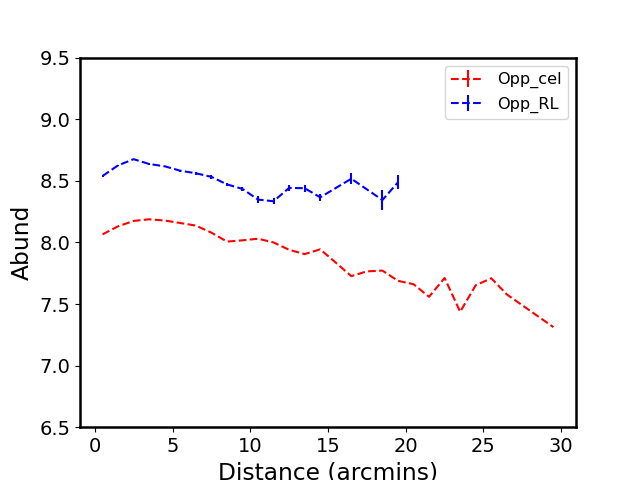

In [108]:
snr = table['int_NII_OII_flux4']/table['int_NII_OII_flux4_err']
sel = snr>3
snr_cel = table['int_[OIII]4363_flux1']/table['int_[OIII]4363_flux1_err']
selcel = snr_cel>3

plt.errorbar(diag['distance'][selcel], diag['Opp_cel'][selcel], yerr = diag['Opp_cel_err'][selcel], linestyle = '--', c= 'r', label='Opp_cel')
plt.errorbar(diag['distance'][sel], diag['Opp_RL'][sel], yerr =  diag['Opp_RL_err'][sel],  linestyle = '--', c= 'b', label='Opp_RL')

plt.ylabel('Abund')
plt.xlabel('Distance (arcmins)')
plt.ylim(6.5, 9.5)
plt.legend()
plt.show()

In [112]:
plt.close()

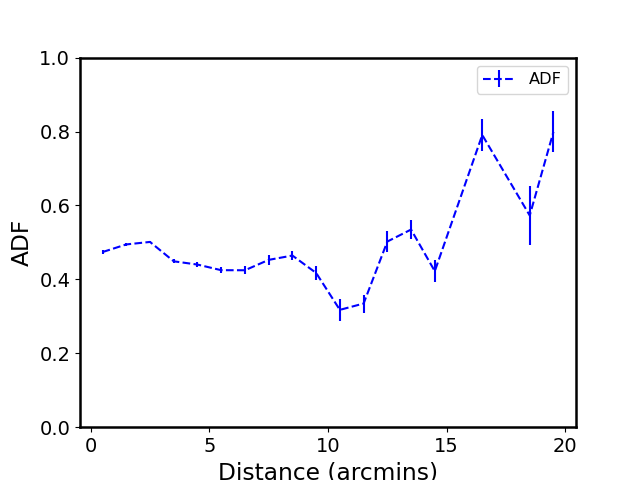

In [113]:
def calculate_adf(Opp_cel, Opp_rl, Opp_cel_err, Opp_rl_err):
 
    Opp_RL_abund_linear = 10**(Opp_rl - 12) 
    Opp_cel_linear = 10**(Opp_cel - 12)

    # errors to linear scale
    Opp_RL_abund_linear_err = Opp_RL_abund_linear * np.log(10) * Opp_rl_err
    Opp_cel_linear_err = Opp_cel_linear * np.log(10) * Opp_cel_err

    # ADF in linear scale
    ADF_linear = Opp_RL_abund_linear / Opp_cel_linear

    # error on ADF in linear scale
    ADF_linear_err = ADF_linear * np.sqrt((Opp_RL_abund_linear_err / Opp_RL_abund_linear)**2 + 
                                          (Opp_cel_linear_err / Opp_cel_linear)**2)

    # ADF and its error back to logarithmic scale
    dex = np.log10(ADF_linear)
    err_dex = ADF_linear_err / (ADF_linear * np.log(10))

    return dex, err_dex

dex, err_dex = calculate_adf(diag['Opp_cel'], diag['Opp_RL'], diag['Opp_cel_err'], diag['Opp_RL_err'])

plt.errorbar(diag['distance'][sel], dex[sel], yerr =  err_dex[sel],  linestyle = '--', c= 'b', label='ADF')

plt.ylabel('ADF')
plt.xlabel('Distance (arcmins)')
plt.ylim(0, 1)
plt.legend()
plt.show()


In [ ]:
############################### Bin spaxels in 1' for radii<30, other wise bin width 8' ################################
with fits.open('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/cond2_corrected_obsv_spectra.fits') as hdu:
        header = hdu[1].header
        data = hdu[1].data

        
def var_radialbin(data, lineid='[OIII]4363', rmin=0, rmax=80):
    '''
    This function will provide the binned line flux for each lineid in each spaxel with constant bin width.
    
    Input:
    data: loading the full table
    data1: table containing signal and noise
    lineid: rest frame wavelength of emission lines
    rmin: minimum radius value in arcmins
    rmax: maximum radius value in arcmins
    
    Returns:
    Radially binned flux, error spectrum with variable width
    '''

    rbinleft = [rmin]
    rbinright = []
    snbin = []
    npix = []

    flux = data['obs_flux']
    error = data['obs_error']
    wave = data['wave'][0]

    signal, noise = data1['obs_' + lineid + '_flux1'], data1['obs_' + lineid + '_flux1_err']

    # Initializing Radii
    RA = data['RA']
    Dec = data['Dec']

    # Assuming Her 36 binary as center for RA and Dec coordinates
    ra_hms = '18 03 40.3201232304'
    dec_dms = '-24 22 42.857540472'

    # Create a SkyCoord object
    coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

    # Converting ra and dec to degrees
    ra_center_deg = coord.ra.deg
    dec_center_deg = coord.dec.deg

    # Calculating the angular distance in degrees
    angular_distances_deg = np.sqrt(((RA - ra_center_deg) * np.cos(np.radians(dec_center_deg)))**2 + (Dec - dec_center_deg)**2)

    # Converting angular distances from degrees to arcminutes
    angular_distances_arcmin = angular_distances_deg * 60  

    radius = angular_distances_arcmin  # for arcminutes

    # Selecting bins based on radius parameters
    selected = (radius >= rmin) & (radius < rmax)
    radius_unique = np.unique(radius[selected])

    snbinned_flux = []
    snbinned_err = []

    current_bin_left = rmin

    while current_bin_left < rmax:

        if current_bin_left < 16:
            bin_width = 1  # arcminute wide bins
        else:
            bin_width = 8  # increase bin width to 8 arcminutes

        current_bin_right = current_bin_left + bin_width
        indices = (radius >= current_bin_left) & (radius < current_bin_right) & selected
        snr_rad = np.nansum(signal[indices]) / np.sqrt(np.nansum(noise[indices]**2))

        if np.any(indices):
            rbinright.append(current_bin_right)
            rbinleft.append(current_bin_left)
            npix.append(np.sum(indices))
            snbin.append(snr_rad)

        if np.sum(indices) > 0:
            snbinned_flux.append(np.nansum(flux[indices, :], axis=0) / npix[-1])
            snbinned_err.append(np.sqrt(np.nansum((error[indices, :]**2), axis=0)) / npix[-1])

        current_bin_left = current_bin_right

    snbinned_flux = np.array(snbinned_flux)
    snbinned_err = np.array(snbinned_err)

    # Writing headers in the fits file
    header = fits.Header()
    hdu_primary = fits.PrimaryHDU(header=header)
    hdu_target = fits.ImageHDU(data=snbinned_flux, name='flux') 
    hdu_errors = fits.ImageHDU(data=snbinned_err, name='error')
    hdu_wave = fits.ImageHDU(data=wave, name='wave')

    newtable = {
        'npix': npix,
        'right_bin': rbinright,
        'sn_bin': snbin }
    
    newtable = Table(newtable)
    hdu_table = fits.BinTableHDU(newtable, name='table')
    hdul = fits.HDUList([hdu_primary, hdu_target, hdu_errors, hdu_wave, hdu_table])

    filename = '/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/annular_binned/lagoon_4363_radbinned_observed_spectrum_var1_8_arcmins.fits'
    hdul.writeto(filename, overwrite=True)

var_radialbin(data, lineid='[OIII]4363', rmin=0, rmax=60)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/cond2_corrected_obsv_spectra.fits'